# <img src="https://lh3.googleusercontent.com/sitesv/AG8ngQVpT360hVirkB1KFIU6-o3fsl8wMEJ33yeSf_fSvO31Fp5jb8MxnQ7EcIHtyGtAYClTdXYU37xiaWf7Cp3UNrt6p8GhVB-BEdtt4HKaHAvmoEebbDBU9B_JxWrLEse8Jahp7tJT3jJY7Vm8wvYPN-VTJBoI_aqB7NsRyXTeE5rEeZ9REaZMWr80FoGB2XCsWscPYRe9VfNrSu2NO0I=w1280" width="100"/> '26: **Reinforcement Learning** — From First Principles to LLM Alignment
---
**Authors**:
* Miruna Pîslar (mirunapislar@google.com)
* Usevalad Milasheuski (usevalad.milasheuski@polimi.it)


Welcome! This tutorial gives a practical, from-first-principles understanding of Reinforcement Learning (RL), with a clear path toward modern **LLM alignment**.

## Tutorial outline

*   **Setup & Installation**
    *   Note: Please run this section first to allow time for downloads to complete while you read the theory sections.
*   **Intro to Reinforcement Learning** — an overview of the core RL concepts.
*   **Part 1 — REINFORCE**: build and train a policy-gradient agent from scratch in a grid-like environment.
*   **Part 2 — Aligning a Language Model with RL**: an introduction to *Reinforcement Learning with Human Feedback (**RLHF**)*; fine-tune a language model to solve grade-school math using *Verifiable Rewards*. We implement the key pieces of **PPO**, **GRPO**, and **DPO** (extra/optional) from scratch.

## Setup and library installations
---

First, let's install and import the libraries we need. **Part 1** uses [gymnasium](https://github.com/Farama-Foundation/Gymnasium) for the environment.

**Part 2** fine-tunes a language model, so it additionally needs HuggingFace [transformers](https://github.com/huggingface/transformers), [peft](https://github.com/huggingface/peft), [datasets](https://github.com/huggingface/datasets) and [trl](https://github.com/huggingface/trl). Everything is installed in the cell right below, so the downloads can run while you read the theory sections.

❗ **Note** Part 1 runs fine on CPU, but **Part 2 needs a GPU**: fine-tuning the LLM is far too slow on CPU, even <1B model. You can do this by clicking `Runtime -> Change runtime type`, and set the hardware accelerator to GPU.

In [ ]:
#@title Downloads.
!pip install -q gymnasium moviepy "peft==0.19.1" "torchao>=0.16" "trl==1.6.0" accelerate datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 13.3 MB/s eta 0:00:00


In [ ]:
#@title Imports & utils
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")  # limit GPU fragmentation
import io
import glob
import re
import base64
import time
from itertools import count

from tqdm.notebook import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
tqdm.pandas()

# Gymnasium environment and Torch.
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

# For visualization
from IPython.display import HTML
from IPython import display as ipythondisplay
from IPython.display import Image

from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [ ]:
#@title Useful functions for Part 1

# A reusable visualization function.
def visualise_policy(
    policy: nn.Module,
    env_id: str = "CliffWalking-v1",
    max_episode_steps: int = 200,
    folder: str = "./videos",
):
    """
    Renders a video of a policy acting in an environment.

    Args:
        env_id (str): The ID of the gymnasium environment.
        policy (nn.Module): The policy to be visualized.
        max_episode_steps (int): The maximum number of steps per episode.
        folder (str): The directory to save the video in.
    """
    # Create a new environment for recording.
    video_env = gym.make(env_id, render_mode="rgb_array")
    recorder_env = RecordVideo(video_env, folder, name_prefix=f"vis-{env_id}")

    state, _ = recorder_env.reset()
    policy.eval() # Set the policy to evaluation mode.

    for _ in range(max_episode_steps):
        with torch.no_grad(): # No need to track gradients for visualization.
            # Ask the policy for action logits (each policy handles its own device).
            action_logits = policy(state)
            if isinstance(action_logits, tuple):  # actor-critic returns (logits, value)
                action_logits, _ = action_logits

            action_probs = F.softmax(action_logits, dim=-1)
            action = Categorical(action_probs).sample().item()

        state, _, terminated, truncated, _ = recorder_env.step(action)
        done = terminated or truncated
        if done:
            break

    recorder_env.close()

    # Display the video.
    mp4list = glob.glob(f'{folder}/*.mp4')
    if len(mp4list) > 0:
        mp4 = sorted(mp4list, key=os.path.getmtime)[-1]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        ipythondisplay.display(HTML(data=f'''<video alt="test" autoplay
                    loop controls style="height: 200px;">
                    <source src="data:video/mp4;base64,{encoded.decode('ascii')}" type="video/mp4" />
                </video>'''))
    else:
        print(f"Could not find video in folder: {folder}")


# Utils for reward shaping.
def get_shaped_reward(
    env: gym.Env,
    original_reward: float,
    state: int,
    next_state: int,
    gamma: float = 0.99,
    still_penalty: float = -2.0,
    potential_multiplier: float = 5.0,
) -> float:
    """
    Calculates a shaped reward to better guide the agent.

    Args:
        env: Environment instance.
        original_reward: Reward received from env.step().
        state: Current state (before the action).
        next_state: Next state (after the action).
        gamma: Discount factor.
        still_penalty: Penalty for not changing the state (i.e., inactivity).
        potential_multiplier: Factor to amplify the potential-based pull.

    Returns:
        The newly calculated shaped reward.
    """
    shaped_reward = original_reward
    # Extra penalty for staying in place / bumping into walls.
    if state == next_state:
        shaped_reward += still_penalty

    # Potential-based reward for reaching the goal (negative distance).
    # Closest to the goal, the potential is higher (less negative).
    unwrapped_env = env.unwrapped
    goal_state = unwrapped_env.observation_space.n - 1
    goal_pos = np.unravel_index(goal_state, unwrapped_env.shape)

    current_pos = np.unravel_index(state, unwrapped_env.shape)
    next_pos = np.unravel_index(next_state, unwrapped_env.shape)

    dist_to_goal_current = np.linalg.norm(np.array(current_pos) - np.array(goal_pos))
    dist_to_goal_next = np.linalg.norm(np.array(next_pos) - np.array(goal_pos))

    potential_current = -potential_multiplier * dist_to_goal_current
    potential_next = -potential_multiplier * dist_to_goal_next

    shaped_reward += (gamma * potential_next - potential_current)

    return shaped_reward

## Intro to Reinforcement Learning
---

Reinforcement Learning (RL) is about learning to make good decisions through trial and error. An **agent** (our learner) interacts with an **environment** (the world or game it's in) by taking **actions**. After each action, the environment provides a **reward** (a score) and a new **state** (the new observation of the world).

This interaction follows a basic loop:

1. The agent observes the current **state** $s_t$.
2. It selects an **action** $a_t$ using its **policy** $\pi$.
3. The environment transitions to a **new state** $s_{t+1}$ and provides a **reward** $r_t$.
4. The cycle repeats.


<img src="https://editor.analyticsvidhya.com/uploads/197201.jpg" alt="agent-environment loop" width="500"/>

<sub>The agent–environment interaction loop. Figure from the [Analytics Vidhya](https://www.analyticsvidhya.com/blog/2021/10/a-comprehensive-guide-to-reinforcement-learning/).</sub>

### 🔁 Key Concepts

* **Timestep** $t$: A single step in the environment, where the agent receives state $s_t$, takes action $a_t$, and gets reward $r_t$ and the next state $s_{t+1}$.

* **Episode**: A full run from a starting state to a terminal state. For example, a full game from start to crash. This is also called a **trial** or a **trajectory**:

  $$
  \tau = (s_0, a_0, r_0, s_1, a_1, r_1, \dots, a_{T-1}, r_{T-1}, s_T),
  $$

  where $T$ is the episode length: the last action is $a_{T-1}$ and the last reward is $r_{T-1}$.

### The environment we'll work with
---

[Gymnasium](https://gymnasium.farama.org/index.html) is a standard suite for loading reinforcement learning environments.

For this tutorial, we will use the [CliffWalking](https://gymnasium.farama.org/environments/toy_text/cliff_walking/) environment. This is a `4x12` grid world environment. The agent starts at the bottom-left corner (at location $[3,0]$) and must reach the goal at the bottom-right (location $[3,11]$). The agent should follow the "safe path" (grass) and avoid the cliff area (in brown), which results in a large penalty if stepped on.

![CliffWalking environment](https://gymnasium.farama.org/_images/cliff_walking.gif)

In [ ]:
#@title Load the "CliffWalking" environment.

env = gym.make("CliffWalking-v1")
num_states = env.observation_space.n
num_actions = env.action_space.n

print(f"Observation space (4x12): {env.observation_space}")
print(f"Action space (up, right, down, left): {env.action_space}")

Observation space (4x12): Discrete(48)
Action space (up, right, down, left): Discrete(4)



The agent's **goal** is to learn the shortest path from the starting position 🪑 to the cookie 🍪.

The agent's **state** is an integer representing the player’s current position, calculated as `current_row * 12 + current_col`. For example, the starting position can be calculated as follows: 3 * 12 + 0 = 36.

The agent's **actions** are simply 4 basic moves, which are represented by 4 integers: UP (coded by 0), RIGHT (1), DOWN (2), and LEFT (3).

The **reward** given by the environment after each step is:

  * `-1` for every step on the safe path (grass).
  * `-100` for falling off the cliff, which also "teleports"
 the agent to the starting position.
  * Once the goal is reached, the agent gets no additional reward, and the episode ends.

**Question:** What is the **maximum** total reward the agent can receive if it achieves its goal?
<details><summary>Answer</summary>

The answer is **−13**: the shortest safe route is UP, then RIGHT×11, then DOWN = 13 steps, each costing −1
</details>

### 🎯 Goal: maximize expected reward
---

In reinforcement learning, the agent’s goal is to collect as much reward as possible over time. We define this using the **return**, denoted $G_t$, which is the **discounted sum of future rewards starting at time step $t$**:

$$
G_t = \sum_{k=0}^{∞} \gamma^{k} r_{t+k}
$$

where $r_{t+k}$ is the reward received $k$ steps into the future (so $r_t$ is the immediate reward).

Here, $\gamma \in [0,1]$ is the **discount factor**. It determines how much the agent prioritizes long-term rewards over short-term ones. A discount factor close to 1 (e.g., 0.99) means the agent considers future rewards nearly as important as immediate rewards, whereas a value closer to 0 makes it focus more heavily on short-term outcomes.

> 💡 Although often treated as a hyperparameter, $\gamma$ is better viewed as part of the **problem definition**, not just something to tune for performance (like the learning rate).


#### ✏️ **Exercise: Calculate the discounted returns $G_t$**

Let's calculate the **discounted return** $G_t$ for every step $t$ in an episode. This value represents the total future reward from that step onwards.

For an episode that ends at a final timestep $T$ (e.g., by reaching the goal or reaching the imposed maximum number of steps), the discounted return is the finite sum:

$$
G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \dots + \gamma^{T-1-t} r_{T-1} = \sum_{k=0}^{T-1-t} \gamma^k r_{t+k}
$$

Now, let's implement this logic in code.

> Hint: Can you define this recursively?

<details>
<summary>💡 Hints</summary>

* Use the recursive form: $G_t = r_t + \gamma G_{t+1}$.

*   The easiest way is to work backward from the last reward to the first.

*   Keep a running total for the return, starting at 0.

*   In each backward step, update the total using the formula: `return = reward + gamma * return`.

*   Add each new return you calculate to the front of your results list.

*   Python's `reversed()` function is perfect for looping backward
</details>

<details>
<summary>Note</summary>
In practice, we standardize $G_t$ before computing the loss: $\hat G_t = (G_t - \bar G)/\sigma_G$. This reduces variance and improves training stability. The get_returns function handles this by default.

</details>

In [ ]:
#@title ✏️ Exercise: Implement the discounted return for each step t in [0, T-1]

def get_returns(gamma: float, rewards: list[float], standardize: bool = True) -> torch.Tensor:
    """
    Calculates the discounted returns for the entire rewards history.
    """
    # Heads-up on indexing: here `rewards[t]` is the *immediate* reward at step t,
    # and G_t includes it -> G_t = r_t + g*r_{t+1} + ... (that's the "t+k" form).
    # Textbooks (Sutton & Barto) call that same reward R_{t+1} and write "t+k+1".
    # Same returns, just different naming. Our test below uses the t+k convention.
    returns = []
    discounted_return = 0

    ################################################################
    # Compute the returns for each step.
    # YOUR CODE HERE
    raise NotImplementedError()
    ################################################################

    # Cast to float.
    returns = torch.tensor(returns, dtype=torch.float32, device=device)

    # Standardize returns for stability (optional, but good practice).
    if standardize:
      eps = 1e-9  # Small constant for numerical stability.
      returns = (returns - returns.mean()) / (returns.std(correction=0) + eps)  # correction=0 avoids NaN on 1-step episodes

    return returns


In [ ]:
#@title Test your implementation!

def test_get_returns():
    rewards = [1, 1, 1]  # Simple reward sequence.
    gamma = 0.9

    # Expected discounted returns (no standardization):
    # G_0 = 1 + 0.9*1 + 0.9^2*1 = 1 + 0.9 + 0.81 = 2.71
    # G_1 = 1 + 0.9*1 = 1 + 0.9 = 1.9
    # G_2 = 1
    expected_returns = torch.tensor([2.71, 1.9, 1.0], dtype=torch.float32)

    returns_unstandardized = get_returns(gamma, rewards, standardize=False)

    assert torch.allclose(returns_unstandardized.cpu(), expected_returns, atol=1e-2), \
        f"Expected {expected_returns}, but got {returns_unstandardized}"

    print("✅ Test passed: discounted returns are correct!")

test_get_returns()

✅ Test passed: discounted returns are correct!


### Agent Policy
---

The agent's "brain" is its **Policy ($\pi$)**, which is a function that decides which action to take in a given state.

Formally, a policy is a mapping from states to a probability distribution over actions.

$$
\pi(a | s) = \text{probability of taking action } a \text{ in state } s
$$

This means that in a state $s$, the policy doesn't just output a single best action. Instead, it gives a probability for *every* possible action. This allows the agent to explore by sometimes trying actions that don't have the highest probability, which is crucial for discovering new, better strategies.

### From Policy Output to Action

So, how do we get from a state to a concrete action? It's a simple three-step process:

1.  **Get Action Scores (Logits)**: The policy takes the current state and outputs a raw score for each possible action; these scores are called **logits**.

2.  **Convert to Probabilities (Softmax)**: Logits are just numbers; they can be positive or negative and don't sum to 1. To turn them into a valid probability distribution, we use the **softmax function**.

    `Logits [3.2, -1.7, 0.4, 5.8] (UP/RIGHT/DOWN/LEFT) →  Softmax  →  Probabilities [0.0688, 0.0005, 0.0042, 0.9265]`

3.  **Sample an Action**: The agent then samples an action from this probability distribution. This means an action with a higher probability is more likely to be chosen, but it's not guaranteed.

This entire process ensures that the agent's actions are guided by its learned preferences (the logits) while still allowing for **exploration**.

### Implementing a Policy

We can implement a policy in different ways. The two we will cover are:

*   **Tabular Policy**: A simple lookup table. For each state, we store a list of action logits. This works perfectly for small environments like CliffWalking where we can list every possible state.
*   **Neural Network Policy**: A more powerful function approximator that can handle environments with big or continuous state spaces (e.g., controlling a robot from camera images).

We will start with a tabular policy, as it's the easiest to understand and implement.

#### ✏️ **Exercise: Implement a tabular policy**

Let's build a tabular policy called `GridPolicy`. The `forward` method has already been completed: it takes an observation (the agent's current location) and returns action logits.

Your task is to instantiate the policy: create a learnable table of size `[number of states, number of actions]`. This table will hold the policy's logits.

<details>
<summary>💡 Hints</summary>

*   First, create a tensor of random values using `torch.randn()`.

* Think about the shape of this tabular policy: what is the shape of the table? Does it depend on the environment?

*   To make this tensor a learnable parameter of the module, wrap the tensor you created inside `nn.Parameter()`.

</details>

In [ ]:
class GridPolicy(nn.Module):
    """
    A policy for environments with a discrete state space (like a grid).
    It's a simple table mapping each state to action logits.
    """
    def __init__(self, num_states: int, num_actions: int):
        super().__init__()
        ################################################################
        # Create a learnable parameter of size [num_states, num_actions].
        # Initialize as zeros
        # YOUR CODE HERE
        raise NotImplementedError()
        ################################################################

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        """
        Given an observation (state), return action logits.
        """
        action_logits = self.policy[int(obs)] # [num_actions]; int() keeps indexing device-safe
        return action_logits


In [ ]:
# Let's instantiate the Grid policy and print the action logits for a custom state.

untrained_grid_policy = GridPolicy(num_states=num_states, num_actions=num_actions).to(device)
test_obs = 36  #@param
logits = untrained_grid_policy(test_obs)
print(f"Action logits for state {test_obs}: {logits.detach().cpu().numpy()}")

# We can also use PyTorch's Categorical distribution to see the probabilities
# and sample an action.
action_distribution = Categorical(logits=logits)
probabilities = action_distribution.probs
sampled_action = action_distribution.sample()

print(f"Probabilities: {probabilities.detach().cpu().numpy()}")
print(f"Sampled Action: {sampled_action.item()}")

Action logits for state 36: [ 0.7531997   0.99938357 -2.641247   -0.87861246]
Probabilities: [0.39868137 0.5099672  0.0133794  0.07797204]
Sampled Action: 3


In [ ]:
#@title Watch your untrained GridPolicy *random* agent!

print("Visualizing an untrained GridPolicy with random weights...")
visualise_policy(
    policy=untrained_grid_policy,
    max_episode_steps=50,
)

Visualizing an untrained GridPolicy with random weights...


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


# 🛠️ Part 1: REINFORCE

### The REINFORCE algorithm
---

We have a policy, but how does it actually learn which actions to take?

We'll use a famous policy gradient algorithm called **REINFORCE**. The core idea is intuitive:

> If a trajectory had a high return, increase the probability of the actions taken in that trajectory. If it had a low return, decrease their probability.

This is a form of trial-and-error learning. We're "reinforcing" good behaviors.

### Agent's goal: maximizing expected return
---

Mathematically, our goal is to find the policy parameters, $\theta$, that maximize the expected total discounted return, which is our objective function $J(\theta)$.

$$
\max_{\theta} J(\theta) \quad \text{where} \quad J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}[G(\tau)]
$$

This means we want to find the parameters $\theta$ that, on average, produce trajectories ($\tau$) with the highest possible total return $G(\tau)$. The standard way to maximize a function is **gradient ascent**: we calculate the gradient of the objective with respect to the parameters, $\nabla_\theta J(\theta)$, and take a small step in that direction.

$$
\theta \leftarrow \theta + \eta \nabla_\theta J(\theta)
$$

where $\eta$ is the learning rate.


<details>

<summary> Challenge: finding the Policy Gradient</summary>

The tricky part is calculating the gradient $\nabla_\theta J(\theta)$. Let's write out the expectation to see why:

$$
\nabla_\theta J(\theta) = \nabla_\theta \mathbb{E}_{\tau \sim \pi_\theta}[G(\tau)] = \nabla_\theta \sum_{\tau} P(\tau|\theta) G(\tau)
$$

Here, $P(\tau|\theta)$ is the probability of a specific trajectory $\tau$ occurring under our policy $\pi_\theta$. We run into two major problems:

1.  **The gradient is outside an expectation that depends on $\theta$**. The distribution of trajectories we sample from, $P(\tau|\theta)$, changes as we change our policy parameters $\theta$. We can't just move the gradient inside the expectation, because the thing we are averaging over depends on the variable we're differentiating with respect to.

2.  **The trajectory probability depends on the unknown environment dynamics**. The probability of a trajectory is a product of the policy's action probabilities and the environment's transition probabilities:

$$
P(\tau|\theta) = p(s_0) \prod_{t=0}^{T-1} \underbrace{\pi_\theta(a_t|s_t)}_{\text{Our policy}} \cdot \underbrace{p(s_{t+1}|s_t, a_t)}_{\text{Environment}}
$$

To compute the gradient $\nabla_\theta P(\tau|\theta)$, we would need to know the environment dynamics, $p(s_{t+1}|s_t, a_t)$, which in most interesting problems is unknown and complex. We can't differentiate a function we don't know!

We seem to be stuck. How can we get a gradient that depends only on our policy and is easy to estimate from experience? This is where the **Policy Gradient Theorem** comes to the rescue.

The theorem provides a clever way to rewrite the gradient, turning an intractable problem into a solvable one. It accomplishes two things: it moves the gradient operator *inside* the expectation, and it eliminates the need for the environment model.

</details>

<details>
<summary> The Log Trick </summary>

The key mathematical insight is a simple identity from calculus called the "log-derivative trick" or "log-prob trick": for any positive, differentiable function $f(x)$, its derivative can be written as:

$$
\nabla f(x) = f(x) \frac{\nabla f(x)}{f(x)} = f(x) \nabla \log f(x)
$$

We can apply this to our trajectory probability, $P(\tau|\theta)$:

$$
\nabla_\theta P(\tau|\theta) = P(\tau|\theta) \nabla_\theta \log P(\tau|\theta)
$$

Now we can substitute this back into our gradient calculation:

$$
\begin{aligned}
\nabla_\theta J(\theta) &= \nabla_\theta \sum_{\tau} P(\tau|\theta) G(\tau) \\
&= \sum_{\tau} \nabla_\theta P(\tau|\theta) G(\tau) \\
&= \sum_{\tau} P(\tau|\theta) \nabla_\theta \log P(\tau|\theta) G(\tau) \\
&= \mathbb{E}_{\tau \sim \pi_\theta} \left[ G(\tau) \cdot \nabla_\theta \log P(\tau|\theta) \right]
\end{aligned}
$$

This is a beautiful result! We've successfully moved the gradient operator inside the expectation. Now, we can estimate this gradient by simply running our policy and averaging the results—a **Monte Carlo** approach.

</details>


<details>
<summary> Getting rid of the environment model </summary>

But what about the second problem? Doesn't $\nabla_\theta \log P(\tau|\theta)$ still depend on the environment dynamics? Let's expand it.

Remember, the log of a product is the sum of logs:

$$
\log P(\tau|\theta) = \log p(s_0) + \sum_{t=0}^{T-1} \left( \log \pi_\theta(a_t|s_t) + \log p(s_{t+1}|s_t, a_t) \right)
$$

Now, let's take the gradient with respect to our policy parameters, $\theta$:

$$
\nabla_\theta \log P(\tau|\theta) = \nabla_\theta \left[ \log p(s_0) + \sum_{t=0}^{T-1} \log \pi_\theta(a_t|s_t) + \sum_{t=0}^{T-1} \log p(s_{t+1}|s_t, a_t) \right]
$$

The parameters $\theta$ are only in our policy, $\pi_\theta$. The environment dynamics $p(s_{t+1}|s_t, a_t)$ and the initial state distribution $p(s_0)$ **do not depend on $\theta$**. Therefore, their gradients are zero!

$$
\nabla_\theta \log P(\tau|\theta) = \sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta(a_t|s_t)
$$

This is the final piece of the puzzle. The gradient of the log-probability of a trajectory is just the sum of the gradients of the log-probabilities of the actions taken.

</details>

<details>
<summary>Further reading</summary>

Check out [Lil'Log blogpost](https://lilianweng.github.io/posts/2018-04-08-policy-gradient/) about policy gradient algorithms.

</details>

### From theory to practice: the REINFORCE update rule
---

Combining our results, we get the final expression for the policy gradient:

$$
\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} \left[ G(\tau) \sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta(a_t|s_t) \right]
$$


This is an expectation, which we can approximate by running our policy to collect a batch of $N$ episodes (trajectories) and then averaging the results.

One final, crucial optimization is based on **causality**. The action taken at timestep $t$ can only affect rewards from timestep $t$ onwards. It cannot affect past rewards. Therefore, to credit an action $a_t$, we should only use the return starting from that step, $G_t$.


Replacing the full trajectory return $G(\tau)$ with $G_t$ for each action's gradient term reduces variance and leads to more stable and faster learning.

This gives us our final, practical formula for the gradient, which is the core of the **REINFORCE** algorithm. We estimate it by averaging over all the steps in our batch of episodes:

$$
\nabla_\theta J(\theta) \approx \frac{1}{N} \sum_{i=1}^{N} \sum_{t=0}^{T_i-1} G_{i,t} \cdot \nabla_\theta \log \pi_\theta(a_{i,t} | s_{i,t})
$$

👨‍💻 Let's break this down one last time:
*   We collect a batch of $N$ trajectories using our current policy $\pi_\theta$.
*   For each step $t$ in each trajectory $i$:
    *   We calculate the return, $G_{i,t}$.
    *   We calculate the gradient of the log-probability of the action we took, $\nabla_\theta \log \pi_\theta(a_{i,t} | s_{i,t})$. This term tells us which direction in parameter space would make that action more likely.
    *   We scale this direction vector by the return $G_{i,t}$. If the future return was high, we push the parameters in that direction. If it was low (or negative), we push them in the opposite direction.
*   We average all these scaled vectors together to get our final estimate of the policy gradient, and then update our parameters $\theta$.

✨ In the next exercise, you will implement the REINFORCE loss function.

### Building a learning agent: implementation considerations
---

To keep our code clean and easy to understand, we'll separate our learning system into 3 components: the **Policy**, the **Agent**, and the **Algorithm**.

1.  **Policy**: the "brain" of our operation.
    *   **Role**: To decide which action to take in a given state. It maps a state to action logits. It contains the learnable parameters (the weights).
    *   **Implementation**: The `GridPolicy`/`NNPolicy`

2.  **Agent**: the "body" or the complete entity that interacts with the world.
    *   **Role**: It holds a policy and uses it to act in the environment. It's also responsible for collecting experience (the sequences of states, actions, and rewards). Crucially, it orchestrates the entire learning process.
    *   **Implementation**: We will soon create a class called `ReinforceAgent`.

3.  **Learning Algorithm**: the "training rule" that enables learning.
    *   **Role**: It takes the experience collected by the Agent and uses it to update the Policy's parameters, making the policy better over time.
    *   **Implementation**: The algorithm is the logic *inside* our Agent's `.update()` method. In this tutorial, the algorithm we will implement is called **REINFORCE**.

This modular design is very convenient. Our `ReinforceAgent` will be able to train *any* kind of policy (`GridPolicy`, `NNPolicy`, etc.) because the learning algorithm is separate from the policy's internal structure.

```
┌────────────────────────────────┐
│   ReinforceAgent               │
│  (The complete learner)        │
│                                │
│   ┌────────────────────────┐   │  <── The Agent HOLDS a Policy
│   │         Policy         │   │
│   │ (e.g., GridPolicy or   │   │
│   │      NNPolicy)         │   │
│   └────────────────────────┘   │
│                                │
│   → select_action() uses Policy│  <── The Agent USES the Policy to act
│   → update() implements        │  <── The Agent USES the Algorithm to learn
│     REINFORCE Algorithm        │
└────────────────────────────────┘
```

#### ✏️ **Exercise: Implement the REINFORCE Loss**

Now we'll create the `ReinforceAgent`. The Agent takes as input a policy to choose actions (we will re-use the `GridPolicy` you implemented above) and implements the logic for updating the policy's parameters using the REINFORCE algorithm.

Your task is to implement the REINFORCE loss using the `get_returns` function you already implemented above.

> Note: Optimizers in PyTorch perform gradient *descent* (minimization) with respect to the parameters $\theta$ ($x$ in the figure below). As we saw, the objective is to *maximize* $\log \pi_\theta(a_t|s_t) * G_t$ ($F(x)$ in the figure below).

<img src="https://ars.els-cdn.com/content/image/3-s2.0-B9780123813756000024-f02-10-9780123813756.jpg" alt="function and its negative" width="300"/>

The optimum of the function we want to **maximize** is the same for the equivalent negative function we want to **minimize**. Thus we'll implement our loss as the *negative* of the original objective:

$$ \text{REINFORCE loss} = - \sum_{t=0}^{T-1} \log \pi_\theta(a_t | s_t) \cdot G_t $$

<details>
<summary>💡 Hints</summary>

*   Your goal is to translate the REINFORCE loss formula into code.
* "Call get_returns(gamma=self.gamma, rewards=episode_rewards) to turn the rewards into standardized discounted returns."

*   Multiply the `log_probs` tensor with the `returns` tensor. This operation is element-wise.

*   Sum up all the elements of the resulting tensor to get a single scalar value. The `torch.sum()` function is what you need.

*   Remember to put a negative sign in front of the final sum. This is because optimizers minimize a loss, but we want to maximize our objective.

</details>

In [ ]:
class ReinforceAgent(nn.Module):
    """Implements the REINFORCE algorithm."""

    def __init__(self, policy: nn.Module, gamma: float = 0.99):
        super().__init__()
        self.policy = policy
        self.gamma = gamma

    def forward(self, obs: int) -> tuple[int, torch.Tensor]:
        """
        Selects an action and returns it along with its log-probability.

        Args:
            obs: The current observation (state) from the environment.

        Returns:
            A tuple containing:
            - int: The action selected by the policy.
            - torch.Tensor: The log-probability of the selected action.
        """
        # Get action logits from the policy network.
        logits = self.policy(obs) # [num_actions]

        # Create a probability distribution directly from logits.
        distribution = Categorical(logits=logits)

        # Sample an action from the distribution and get log-prob.
        action = distribution.sample()
        log_prob_action = distribution.log_prob(action)
        return action.item(), log_prob_action

    def calculate_reinforce_loss(
        self, episode_rewards: list[float], log_probs: torch.Tensor
    ) -> torch.Tensor:
        """
        Calculates the REINFORCE loss for a single episode.

        Args:
            episode_rewards: The list of rewards collected during the episode.
            log_probs: A tensor of the log_probs for the actions in that episode.

        Returns:
            A tensor representing the calculated loss for the episode.
        """
        ################################################################
        # Calculate the REINFORCE loss.
        # YOUR CODE HERE
        raise NotImplementedError()
        ################################################################
        return loss

    def update(
        self,
        batch_log_probs: list[list[torch.Tensor]],
        batch_rewards: list[list[float]],
        optimizer: optim.Optimizer,
    ):
        """
        Performs the learning step for a batch of episodes.

         For each episode in the batch:
            * Stacks the log_probs into a tensor.
            * Computes the REINFORCE loss (which internally computes discounted returns).
            * Appends the episode loss to the list of losses.
        Then, it averages the losses across the batch and performs a gradient
        ascent step to update the policy.
        """
        batch_loss = []
        # Iterate over each episode in the batch.
        for episode_rewards, episode_log_probs in zip(batch_rewards, batch_log_probs):
            log_probs = torch.stack(episode_log_probs)
            episode_loss = self.calculate_reinforce_loss(episode_rewards, log_probs)
            batch_loss.append(episode_loss)
        average_batch_loss = torch.stack(batch_loss).mean()

        # Perform the gradient ascent step (since we used '-' before the loss)
        optimizer.zero_grad()
        average_batch_loss.backward()
        optimizer.step()

In [ ]:
#@title Test your implementation of the `calculate_reinforce_loss` method.

def test_agent_loss_method():
    agent = ReinforceAgent(policy=untrained_grid_policy, gamma=0.99)
    episode_rewards = [2.0, -0.5, -1.0]   # raw rewards, as update() passes them
    log_probs = torch.tensor([-0.5, -1.0, -0.2], device=device)

    calculated_loss = agent.calculate_reinforce_loss(episode_rewards, log_probs)

    # By hand: discounted returns (gamma=0.99) = [0.5249, -1.49, -1.0]
    # -> standardized = [1.3752, -0.9732, -0.4021]
    # -> loss = -sum(log_probs * returns) = -0.3660
    expected_loss = torch.tensor(-0.3660, device=device)

    if torch.isclose(calculated_loss, expected_loss, atol=1e-3):
        print("✅ TEST PASSED!")
    else:
        print("❌ TEST FAILED!")
    print(f"Your loss: {calculated_loss.item():.4f}, expected: {expected_loss.item():.4f}")

test_agent_loss_method()

✅ TEST PASSED!
Your loss: -0.3660, expected: -0.3660


### Training loop for the REINFORCE Agent

We now have all the components. The final step is to orchestrate the agent-environment interaction. The loop will look like this:

1.  Play a number of episodes (`episodes_per_batch`).
2.  In each episode:
    -   Reset the environment.
    -   Loop until the episode is `done` (terminated or truncated):
        -   The agent chooses an action.
        -   The environment gives a new state and reward.
        -   Store the reward in the agent's history.
3.  After collecting data from the batch, call `agent.update()` to learn.
4.  Repeat for a number of updates.

Read through the training loop implementation below.

In [ ]:
#@title The generic training loop for REINFORCE agents.
def train_agent(
    env: gym.Env,
    agent: ReinforceAgent,
    optimizer: optim.Optimizer,
    num_updates: int,
    episodes_per_batch: int,
    max_episode_steps: int,
    convergence_threshold: float,
):
    """
    A generic function to train a REINFORCE agent.

    Args:
        env: The gymnasium environment to train in.
        agent: The ReinforceAgent to train.
        optimizer: The optimizer for the agent's policy.
        num_updates: The total number of policy updates to perform.
        episodes_per_batch: The number of episodes to run per policy update.
        max_episode_steps: The maximum steps allowed per episode.
        convergence_threshold: The average reward to aim for to "solve" the env.

    Returns:
        A list of avg_rewards for plotting.
    """
    avg_rewards = []

    print(f"Starting training for {agent.policy.__class__.__name__}...")
    pbar = tqdm(range(num_updates), mininterval=2)
    for i in pbar:
        # These lists will store the experience for the entire batch.
        batch_rewards = []
        batch_log_probs = []
        batch_episode_rewards = []

        for _ in range(episodes_per_batch):
            episode_rewards = []
            episode_log_probs = []
            total_episode_reward = 0
            state, _ = env.reset()

            for _ in range(max_episode_steps):

                # Get action & log_prob from the agent.
                action, log_prob = agent(state)
                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated

                # *** Apply reward shaping for faster convergence ***
                shaped_reward = get_shaped_reward(env, reward, state, next_state)

                # Store experience for the current episode.
                episode_rewards.append(shaped_reward)
                episode_log_probs.append(log_prob)
                total_episode_reward += reward
                state = next_state

                if done:
                    break

            # After the episode is done, add its history to the batch history.
            batch_rewards.append(episode_rewards)
            batch_log_probs.append(episode_log_probs)
            batch_episode_rewards.append(total_episode_reward)

        # 2. Update the agent's policy using the collected batch of experience.
        agent.update(batch_log_probs, batch_rewards, optimizer)

        # 3. Logging.
        avg_reward_for_batch = np.mean(batch_episode_rewards)
        avg_rewards.append(avg_reward_for_batch)

        pbar.set_postfix(avg_reward=f"{avg_reward_for_batch:.2f}")

        # 4. Check for convergence.
        if avg_reward_for_batch > convergence_threshold:
            print(f"\nSolved at update {i}!")
            break

    return avg_rewards

<details>
<summary> Note for a curious reader: Reward Shaping — what it is and why it's here</summary>

CliffWalking's reward is **sparse**: you get `-1` per step and nothing tells you whether you're heading toward the goal until you reach it. For REINFORCE, which learns only from the returns of *complete* episodes, this is slow — a randomly exploring agent can take a long time to stumble onto the goal even once.

To speed up the live demo, the training loop adds a small **shaping reward** on top of the environment's reward (see `get_shaped_reward` in the setup section):

* a **potential-based bonus** $\gamma\,\Phi(s') - \Phi(s)$, where $\Phi(s)$ grows as the agent gets closer to the goal — this gently rewards progress;
* a small **penalty for not moving** (e.g. bumping into a wall), to discourage the agent from getting stuck.

> 💡 The potential-based term is special: Ng, Harada & Russell (1999) showed that shaping of the form $\gamma\Phi(s') - \Phi(s)$ **does not change the optimal policy** — it only reshapes the *learning signal*, not the goal. (The anti-stalling penalty is a small extra heuristic, not part of that guarantee.)

**Important:** shaping is a practical training trick, **not** part of REINFORCE. The algorithm you implemented is unchanged. We also still **log** the raw environment reward, so the curve and the "solved" threshold stay on the real `-1`-per-step scale you reasoned about earlier — only the *learning* signal is shaped.

</details>

Let's run the training loop for the ReinforceAgent training a GridPolicy.

There's nothing for you to code, but feel free to experiment with the hyperparameters! 🚀

In [ ]:
# @title Run the Reinforce agent with a GridPolicy
# --- Hyperparameters ---
TABULAR_LEARNING_RATE = 0.1  # @param
TABULAR_GAMMA = 0.99  # @param
TABULAR_NUM_UPDATES = 300  # @param
TABULAR_EPISODES_PER_BATCH = 10  # @param
TABULAR_MAX_EPISODE_STEPS = 100  # @param


# --- Initialization ---
untrained_grid_policy = GridPolicy(num_states, num_actions).to(device)
grid_agent = ReinforceAgent(untrained_grid_policy, gamma=TABULAR_GAMMA)
grid_optimizer = optim.Adam(untrained_grid_policy.parameters(), lr=TABULAR_LEARNING_RATE)


# --- Run Training ---
grid_avg_rewards = train_agent(
    env=env,
    agent=grid_agent,
    optimizer=grid_optimizer,
    num_updates=TABULAR_NUM_UPDATES,
    episodes_per_batch=TABULAR_EPISODES_PER_BATCH,
    max_episode_steps=TABULAR_MAX_EPISODE_STEPS,
    convergence_threshold=-15
)

Starting training for GridPolicy...


  0%|          | 0/300 [00:00<?, ?it/s]

Let's plot the learning progress. You should see the average reward increase 📈.

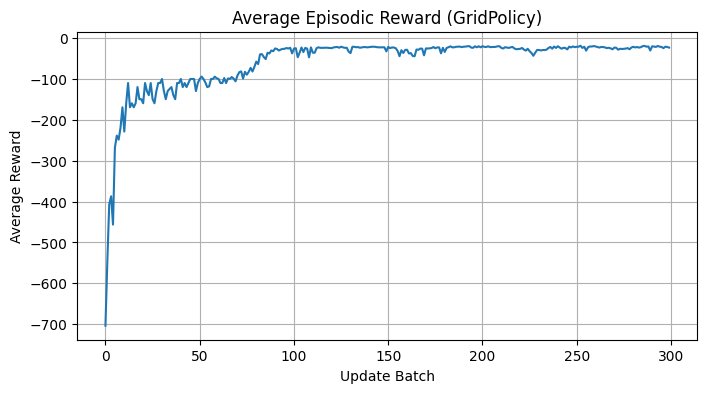

In [ ]:
#@title Plotting learning progress for the Reinforce Agent with GridPolicy.
plt.figure(figsize=(8, 4))
plt.plot(grid_avg_rewards)
plt.title("Average Episodic Reward (GridPolicy)")
plt.xlabel("Update Batch")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

In [ ]:
#@title Watch your trained GridPolicy REINFORCE agent!

visualise_policy(
    policy=grid_agent.policy,
    max_episode_steps=TABULAR_MAX_EPISODE_STEPS
)

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


### A More General Approach: The Neural Network Policy

Our `GridPolicy` (a lookup table) worked, but for larger or continuous state spaces, tables quickly become impractical.

We can replace our specialized table with a general-purpose **function approximator**: a neural network (NN) 🕸️. While it may seem like overkill here, it's a good exercise to show how we can apply these more powerful models.

Neural networks require inputs to be vectors, not single integers. So we need to convert a state like `27` into a vector format.

The standard method is **one-hot encoding**: we create a vector with one entry for each possible state (e.g., 48 total), all set to `0`, and set the element at index `27` to `1`.

For example:

```
state = 27  
=>  
one_hot_vector = [0, 0, ..., 1, 0, ...]  # 1 at index 27
```

Now, let’s build a policy that performs this encoding and feeds the result into a simple MLP.

#### ✏️ **Exercise: Define the NN Architecture**

First, complete the `__init__` method by defining a simple 2-3 layer MLP using `nn.Sequential`. Make sure that your input dimension will be the total number of states. Then, complete the `forward` method. This is where you'll convert the integer observation into a one-hot vector before passing it to your network.

<details>
<summary>💡 Hints</summary>

For the `__init__` method:

*   Use `nn.Sequential` to define the network architecture.
*   Your **first** layer should be an `nn.Linear` that maps `num_states` to a hidden size (e.g., 32).
*   Follow this with an `nn.ReLU()` activation function.
*   Your **last** layer should be an `nn.Linear` that maps the hidden size to `num_actions`.
*   Feel free to add extra layers and play with the number of hidden sizes.

For the `forward` method:

*   Use the `F.one_hot()` function to convert the integer observation into a one-hot vector.
*   Make sure to set the `num_classes` argument in `F.one_hot()` to `self.num_states`.

</details>

In [ ]:
class NNPolicy(nn.Module):
    """
    A policy parameterized by a neural network. It uses one-hot encoding
    to handle discrete state spaces.
    """
    def __init__(self, num_states: int, num_actions: int):
        super().__init__()
        self.num_states = num_states

        ################################################################
        # Build a simple 2-3 layer MLP for the policy.
        # YOUR CODE HERE
        raise NotImplementedError()
        ################################################################

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        """
        Performs a forward pass. It takes an integer observation,
        converts it to a one-hot vector, and passes it through the network.
        """
        # Make obs a Long index tensor on the right device (given scaffolding).
        obs = torch.as_tensor(obs, dtype=torch.long, device=device)
        ################################################################
        # Convert the observation tensor to a one-hot vector of Float.
        # YOUR CODE HERE
        raise NotImplementedError()
        ################################################################

        # Pass the one-hot vector through the network to get logits.
        action_logits = self.policy_net(one_hot_obs)
        return action_logits


### Training loop for the `NNPolicy` REINFORCE Agent

Just like before, our modular `ReinforceAgent` can use this new policy without any changes to its own code. We simply instantiate the `NNPolicy` and run the same training loop.

In the code block below, we initialize the `NNPolicy`, the `ReinforceAgent`, and the optimizer. Then, run the training loop to solve `CliffWalking` with your new neural network policy.

In [ ]:
# @title Run the Reinforce agent with a NNPolicy
# --- Hyperparameters for NN on CliffWalking ---
NN_LEARNING_RATE = 0.001  # @param
NN_GAMMA = 0.99  # @param
NN_NUM_UPDATES = 300  # @param
NN_EPISODES_PER_BATCH = 10  # @param
NN_MAX_EPISODE_STEPS = 100  # @param


# --- Initialization ---
untrained_nn_policy = NNPolicy(num_states, num_actions).to(device)
nn_agent = ReinforceAgent(untrained_nn_policy, gamma=NN_GAMMA)
nn_optimizer = optim.Adam(untrained_nn_policy.parameters(), lr=NN_LEARNING_RATE)


# --- Run Training ---
nn_avg_rewards = train_agent(
    env=env,
    agent=nn_agent,
    optimizer=nn_optimizer,
    num_updates=NN_NUM_UPDATES,
    episodes_per_batch=NN_EPISODES_PER_BATCH,
    max_episode_steps=NN_MAX_EPISODE_STEPS,
    convergence_threshold=-14,
)

Starting training for NNPolicy...


  0%|          | 0/300 [00:00<?, ?it/s]

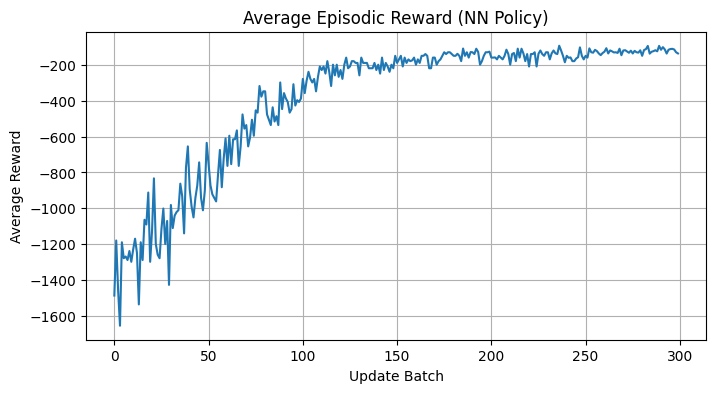

In [ ]:
#@title Plotting learning progress for the Reinforce Agent with NNPolicy.
plt.figure(figsize=(8, 4))
plt.plot(nn_avg_rewards)
plt.title("Average Episodic Reward (NN Policy)")
plt.xlabel("Update Batch")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

In [ ]:
#@title Watch your NN-based agent!

visualise_policy(
    policy=nn_agent.policy,
    max_episode_steps=500,
    folder="./videos_nn"
)

### ✅ Part 1 recap & the road ahead

Congratulations! 🥳 You've built a policy-gradient agent from scratch and trained it with **REINFORCE**.

But REINFORCE has a weakness: it is **high-variance**. The update uses the full return $G_t$ as the weight on $\nabla \log \pi$, which can swing wildly from episode to episode and makes training noisy and unstable — especially for long sequences like *language generation*.

The fixes we need carry us straight into modern LLM alignment:

| Idea | What it does | Shows up in |
|---|---|---|
| **Baseline / advantage** $A_t = G_t - b$ | subtract a baseline to reduce variance | A2C, PPO, GRPO |
| **Value function (critic)** | learn the baseline $V(s)$ | PPO |
| **Clipped objective** | limit how far the policy moves per update | PPO, GRPO |
| **KL penalty** | stay close to a trusted reference policy | RLHF / PPO / GRPO |

In **Part 2**, we'll use exactly these ideas to fine-tune a real language model. 🚀


# 🛠️ Part 2: Aligning a Language Model with RL

We've journeyed from tabular policies to neural networks. Now we scale up to one of the most exciting applications of RL today: **fine-tuning a Large Language Model (LLM)**.

Our concrete goal: take **`Qwen2.5-0.5B-Instruct`** and make it better at solving grade-school math word problems (**GSM8K**) — using *only* a reward signal that checks whether the final answer is correct (this is called **RLVR**: RL with Verifiable Rewards).

### 🧭 The plan for Part 2
We follow one storyline, peeling away components as we go:

1. **PPO** — the workhorse. We write a manual PPO loop (with a value-head critic) on the LLM, using **LoRA** to keep it light enough for a free Colab GPU.
2. **GRPO** — *drop the critic.* Instead of a learned value function, estimate the advantage from a **group** of sampled answers. This is what trained DeepSeek-R1.
3. **DPO** *(extra)* — *drop the sampling.* Optimize directly from a fixed preference dataset, no rollouts needed.

For each of these algorithms, you'll **implement the core parts yourself** (loss / advantage / training loop). We will also provide chunks of code from the `trl` library that run the same thing at scale (more efficient and optimized).


## Mapping RL concepts to LLMs
* **Policy** ($\pi_\theta$) — the LLM itself
* **State** ($s_t$) — the prompt + the tokens generated so far (up to step $t$)
* **Action** ($a_t$) — the **next token** (chosen from the whole vocabulary)
* **Reward** ($r$) — a score for the **finished answer** (usually from a trained reward model $r_\phi(y|x)$; in our case, a rule-based verifier)
* **Episode / rollout** — one full generated response

A full response is a *sequence of actions* (tokens), and the reward typically arrives only at the **end** — a sparse, episodic reward.




<img src="https://ai2-s2-public.s3.amazonaws.com/figures/2017-08-08/6c6189a5fbda8ddf84ef23e5a43f7c85e2120b67/6-Figure3-1.png" alt="ppo loop" width="500"/>

<sub>Basic components of RL and language models (LMs) as agents. Figure from ["A Survey of Reinforcement Learning for Large Reasoning Models"](https://arxiv.org/pdf/2509.08827).</sub>

#### Why RL for LLMs? And why a *verifier* instead of a reward model?

Pre-training teaches an LLM to *imitate* internet text — great at mimicry, but not necessarily **correct** or **aligned**. RL lets us optimize for what we actually want.

In full **RLHF**, step 2 is to train a **reward model** on human preference data. The reward model plays the role the environment plays in classic RL — it scores each completion — but here we *learn* it from human preferences:



<img src="https://raw.githubusercontent.com/natolambert/rlhf-book/main/book/images/rlhf-overview.png" alt="ppo loop" width="500"/>

<sub>Standard RLHF, with a learned **reward model**. Figure from Nathan Lambert's [RLHF Book, Ch. 6 — Policy Gradients](https://rlhfbook.com/c/06-policy-gradients).</sub>


But for tasks with a *checkable* answer — math, code, formatted output — we can skip the reward model entirely and swap in a **rule-based verifier**. This is **RLVR** (RL with Verifiable Rewards): the only change from the picture above is that the reward model box becomes a verification function.

<img src="https://raw.githubusercontent.com/natolambert/rlhf-book/main/book/images/rlvr-system.png" alt="ppo loop" width="500"/>

<sub>RLVR, with a **verifier** in place of the reward model. Figure from Nathan Lambert's [RLHF Book, Ch. 7 — Reasoning](https://rlhfbook.com/c/07-reasoning).</sub>


> GSM8K problems come with a ground-truth number. Our reward = **did the model's final answer match it?** (plus a small bonus for using the right format).

Compared to a learned reward model, a verifier is **cheaper** (no preference data, no second model to train), **unhackable in the obvious ways** (you can't fool exact arithmetic), and gives a **crystal-clear training signal** — which is exactly why it powered recent reasoning models.

#### From REINFORCE to PPO

For language generation, REINFORCE's high variance makes training unstable. **Proximal Policy Optimization (PPO)** fixes this with two ideas you'll implement:

1. **Advantage with a critic.** Instead of the raw return, weight the update by the *advantage* $A_t = G_t - V(s_t)$, where the **value head** $V$ is a small extra output we add to the model. Lower variance.
2. **A clipped objective + KL penalty.** Using the probability ratio $\rho_t = \dfrac{\pi_\theta(a_t\mid s_t)}{\pi_{\theta_{old}}(a_t\mid s_t)}$, PPO maximizes

$$\mathcal{L}^{CLIP} = \mathbb{E}\Big[\min\big(\rho_t A_t,\ \text{clip}(\rho_t, 1-\epsilon, 1+\epsilon)\,A_t\big)\Big] - \beta\, \mathrm{KL}\big[\pi_\theta \,\|\, \pi_{ref}\big]$$

$$\mathrm{KL}(\pi_\theta \,\|\, \pi_{ref})
=
\sum_a \pi_\theta(a)\log\frac{\pi_\theta(a)}{\pi_{\mathrm{ref}}(a)}
=
\mathbb{E}
\left[
\log \pi_\theta(a)-\log \pi_{\mathrm{ref}}(a)
\right]$$

The clip stops the policy from moving too far in one update; the KL penalty keeps it close to a trusted **reference** model (the original LLM) so it doesn't forget how to write.

<img src="https://raw.githubusercontent.com/natolambert/rlhf-book/main/book/images/ppo_tikz.png" alt="ppo loop" width="500"/>

<sub>Figure from Nathan Lambert's [RLHF Book, Ch. 6 — Policy Gradients](https://rlhfbook.com/c/06-policy-gradients).</sub>

**Two frozen models 🧊, two different jobs.** $\pi_{\theta_{old}}$ is the policy frozen at the start of the current rollout — it changes every iteration and lives in the ratio $\rho_t$. $\pi_{ref}$ is the original LLM before any RL fine-tuning — frozen for the whole run, it lives only in the KL penalty. In our code: `logp_old` comes from the rollout; `logp_ref` comes from the base weights (LoRA adapter disabled).

We'll build this loop by hand to break it down better.


In [ ]:
#@title Load Qwen2.5-0.5B-Instruct as a LoRA policy with a value head and the dataset.

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
DTYPE = torch.bfloat16   # bf16 is numerically safe. On a T4 it's correct but not
                         # tensor-core-accelerated; switch to torch.float16 for speed.

# --- Tokenizer (left padding is required for batched generation) ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.padding_side = "left"
# Qwen2.5 already sets pad_token=<|endoftext|> and eos=<|im_end|>, so nothing to fix.

# --- Base model + LoRA adapter (we train only ~1% of the parameters) ---
base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=DTYPE).to(device)

lora_config = LoraConfig(
    r=16, lora_alpha=32, bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
)

# --- The dataset we'll align on: GSM8K grade-school math word problems ---
gsm8k = load_dataset("openai/gsm8k", "main")
print(gsm8k)

# Flat lists of questions/gold answers used by the PPO and GRPO training slices.
train_q = gsm8k["train"]["question"]
train_a = gsm8k["train"]["answer"]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

main/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  419kB            

main/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['question', 'answer'],
        num_rows: 7473
    })
    test: Dataset({
        features: ['question', 'answer'],
        num_rows: 1319
    })
})


In [ ]:
# RUN THIS IF YOU HAVE ISSUES BELOW
#!pip install "torchao>=0.16.0"

In [ ]:
class PolicyWithValueHead(nn.Module):
    """A LoRA-adapted Qwen policy (actor) + a scalar value head (critic).

    Three roles from ONE copy of the weights:
      * policy    pi_theta : the LoRA-adapted model (adapter ON).
      * reference pi_ref   : the SAME model with the adapter DISABLED -> base weights
                             (the memory trick: no second copy of the 0.5B model!).
      * critic    V(s_t)   : a small head reading the last hidden state.
    """

    def __init__(self, base_model, lora_config):
        super().__init__()
        self.lm = get_peft_model(base_model, lora_config)
        hidden_size = base_model.config.hidden_size
        self.value_head = nn.Linear(hidden_size, 1)

        # V(s)=0 at the start, so early advantages equal the true returns
        nn.init.zeros_(self.value_head.weight)
        nn.init.zeros_(self.value_head.bias)

    def forward(self, input_ids, attention_mask):
        """Returns (logits, values) under the current policy."""
        out = self.lm(input_ids=input_ids, attention_mask=attention_mask,
                      output_hidden_states=True)
        # .detach(): the critic is a linear probe on the hidden states. Without
        # it, the value loss would backprop into the LoRA adapter and a poorly
        # trained critic would corrupt the POLICY weights.
        values = self.value_head(out.hidden_states[-1].detach().float()).squeeze(-1)
        return out.logits, values                          # (B, T, V), (B, T)

    @torch.no_grad()
    def reference_logits(self, input_ids, attention_mask):
        """Logits under the frozen reference policy (LoRA adapter disabled)."""
        with self.lm.disable_adapter():
            out = self.lm(input_ids=input_ids, attention_mask=attention_mask)
        return out.logits

    def generate(self, **kwargs):
        return self.lm.generate(**kwargs)


policy = PolicyWithValueHead(base_model, lora_config).to(device)
policy.lm.print_trainable_parameters()

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


In [ ]:
#@title See the BASE model attempt a GSM8K problem (our 'before' baseline).
SYSTEM_PROMPT = (
    "You are a helpful math assistant. Solve the problem step by step, "
    "then give the final numerical answer inside \\boxed{...}."
)


def build_prompt(question: str) -> str:
    """Wrap a question in Qwen's chat template, ready for generation."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)


@torch.no_grad()
def generate_answers(questions, max_new_tokens=256, temperature=1.0,
                     top_p=1.0, do_sample=True):
    """Generate one completion per question. Returns a list of decoded strings."""
    prompts = [build_prompt(q) for q in questions]
    enc = tokenizer(prompts, return_tensors="pt", padding=True).to(device)
    gen = policy.generate(
        input_ids=enc.input_ids, attention_mask=enc.attention_mask,
        max_new_tokens=max_new_tokens, do_sample=do_sample,
        temperature=temperature, top_p=top_p,
        pad_token_id=tokenizer.pad_token_id,
    )
    return tokenizer.batch_decode(gen[:, enc.input_ids.shape[1]:],
                                  skip_special_tokens=True)


# Try it on one test problem.
ex = gsm8k["test"][0]
print("QUESTION:\n", ex["question"])
print("QUESTION (formatted):\n", build_prompt(ex["question"]))
print(50*'-')
print("\nReasoning:\n", ex["answer"].split("####")[0].strip())
print("\nGOLD ANSWER:", ex["answer"].split("####")[-1].strip())
print(50*'-')
print("\nMODEL OUTPUT:\n", generate_answers([ex["question"]], max_new_tokens=512, do_sample=False)[0])


QUESTION:
 Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
QUESTION (formatted):
 <|im_start|>system
You are a helpful math assistant. Solve the problem step by step, then give the final numerical answer inside \boxed{...}.<|im_end|>
<|im_start|>user
Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?<|im_end|>
<|im_start|>assistant

--------------------------------------------------

Reasoning:
 Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.
She makes 9 * 2 = $<<9*2=18>>18 every day at the farmer’s market.

GOLD ANSWER: 18

## 2.1 Designing a reward for GSM8K

Before any RL, we need a **reward function** — our verifier. GSM8K answers end with a line like `#### 42`, giving us the ground-truth number. We reward the model for:

- ✅ **Correctness** (dominant): the final answer matches the ground truth.
- 📐 **Format** (small bonus): the answer is wrapped in `\boxed{...}` (what our system prompt asks for), so it's easy to parse.
- 📏 **Length** (small bonus): the completion's token count falls in a sensible range — not a bare guess, not a runaway ramble.

> ⚠️ Keep correctness clearly *dominant* over format — otherwise the model learns to produce pretty formatting without actually solving anything (**reward hacking**).

####✏️ **Exercise: Implement the GSM8K reward**
In the next cell, implement `extract_prediction` (pull out the model's final number) and `gsm8k_reward` (correctness + format).

<details><summary>💡 Hints</summary>

- `\boxed{...}`: `re.findall(r"\\boxed\{([^}]*)\}", text)` and take the **last** match.
- Fallback to any number: `re.findall(r"-?\d[\d,]*\.?\d*", text)`, take the last, strip commas.
- In `gsm8k_reward`, call `extract_ground_truth(gold_answer)` for the target, then compare with `numbers_match`.
</details>


In [ ]:
# ✏️ Exercise: implement the GSM8K reward function.
def extract_ground_truth(answer_field: str) -> str:
    """GIVEN: GSM8K gold answers end with '#### <number>'."""
    return answer_field.split("####")[-1].strip().replace(",", "")


def numbers_match(a: str, b: str) -> bool:
    """GIVEN: compare two numeric strings, tolerant of formatting."""
    try:
        return abs(float(a) - float(b)) < 1e-4
    except (TypeError, ValueError):
        return False


def extract_prediction(text: str) -> str | None:
    ################################################################
    # TODO: pull the model's final numeric answer out of `text`.
    #   1) Prefer the LAST \boxed{...} (the format our system prompt asks for).
    #   2) Otherwise fall back to the LAST number anywhere in the text.
    #   Return it as a string (strip commas), or None if nothing is found.
    # YOUR CODE HERE
    raise NotImplementedError()
    ################################################################

# Length shaping: reward completions whose LENGTH IN TOKENS is "reasonable".
# Too short = lazy guess with no reasoning; too long = rambling (or truncated
# at the generation cap before ever reaching \boxed{...}).



def gsm8k_reward(completion: str, gold_answer: str) -> float:
    # TODO: combine a DOMINANT correctness reward with two small bonuses.
    #   correctness: +1.0 if extract_prediction(completion) matches
    #                extract_ground_truth(gold_answer)   (use numbers_match)
    #   format:      +0.2 if the completion contains a \boxed{...}
    #   length:      +0.1 if the completion's TOKEN count is within
    #                [MIN_GEN_TOKENS, MAX_GEN_TOKENS] (re-tokenize the string
    #                with `tokenizer(completion, add_special_tokens=False)`)
    #   Return the total reward (a float).
    MIN_GEN_TOKENS, MAX_GEN_TOKENS = 24, 448   # cap is 512; runaways fall outside

    # YOUR CODE HERE
    raise NotImplementedError()
    ################################################################

In [ ]:
#@title Test your reward function.
def test_gsm8k_reward():
    gold = "She had 5 apples and ate 2.\n#### 3"
    cases = [
        ("So the final answer is \\boxed{3}.", 1.2),  # correct + formatted
        ("After adding, the answer is 3.",     1.0),  # correct, no box
        ("Therefore \\boxed{42}.",             0.2),  # formatted but wrong
        ("I'm not sure how to solve this.",    0.0),  # no answer at all
        ("Let me reason step by step. " * 10
         + "So the final answer is \\boxed{3}.", 1.3),  # correct + boxed + in-range length
    ]
    for completion, expected in cases:
        got = gsm8k_reward(completion, gold)
        assert abs(got - expected) < 1e-6, \
            f"reward({completion!r}) = {got}, expected {expected}"
    print("PASSED: reward = correctness (1.0) + format (0.2) + length (0.1)")


test_gsm8k_reward()


PASSED: reward = correctness (1.0) + format (0.2) + length (0.1)


## 2.2 PPO from scratch (with LoRA)

Time to fine-tune the LLM. We'll write the **[Proximal Policy Optimization](https://arxiv.org/abs/1707.06347)** loop **by hand** so every piece is visible. Most of the machinery (generation, log-probs, the training loop) is **given**; the core you implement is the **PPO clipped loss**.

The loop, each step:
1. **Rollout**: sample answers from the current policy for a batch of problems.
2. **Reward**: score each finished answer with `gsm8k_reward`.
3. **Advantage**: $A_t = G_t - V(s_t)$ from the value head.
4. **Optimize**: maximize the clipped surrogate (+ value loss − KL to the reference).

What differs from the original PPO is that step 3 uses the plain Monte-Carlo advantage, while real PPO implementations usually use **GAE**.

<details><summary> Generalized Advantage Estimation (GAE)</summary>

**What we compute.** `rollout` builds per-token returns recursively, $G_t = r_t + \gamma\, G_{t+1}$ — the same formula as Part 1 — and the advantage is $A_t = G_t - V(s_t)$. Since our verifier reward arrives only at the end of the completion, most of the $r_t$ are zero (and with our default $\gamma = 1$, $G_t$ is simply the final reward for every token — a completion has no "sooner is better" preference to encode).

**What GAE would compute.** [GAE (Schulman et al., 2015)](https://arxiv.org/abs/1506.02438) replaces the sampled return with a λ-mixture of *bootstrapped* estimates: $\hat A_t = \sum_l (\gamma\lambda)^l \delta_{t+l}$, where $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$. The knob $\lambda$ trades variance (trust the sampled return, $\lambda = 1$) against bias (trust the critic, $\lambda = 0$). At $\lambda = 1$, **GAE collapses exactly to our $G_t - V(s_t)$** — so we *are* running GAE, just at the corner where the critic is never bootstrapped.

**Why $\lambda < 1$ wouldn't help here.** Bootstrapping pays off when many noisy per-step rewards accumulate over a long horizon. With a single terminal reward, the only randomness is the final outcome itself — which no amount of bootstrapping reduces. $\lambda < 1$ would only add the bias of our barely-trained value head. Frameworks like TRL implement full GAE for the general case; GRPO (next section) drops $V$ — and the whole question — entirely.

</details>


In [ ]:
#@title Helper function 1: per-token log-probs of the chosen tokens.
# Reused by PPO (here), GRPO, and DPO.

def token_logps(logits, input_ids):
    """Log-prob the model assigned to each ACTUAL next token.

    logits:    (B, T, V) from a forward pass over input_ids
    input_ids: (B, T)
    returns:   (B, T-1), where index t holds log pi(input_ids[:, t+1] | ...<=t)
    """
    # Memory-efficient: F.log_softmax would allocate a SECOND (B, T, V) FP32
    # tensor (GBs at vocab=152k). Instead use  log p(x) = logit_x - logsumexp(logits),
    # which only adds (B, T-1) intermediates.
    logits = logits[:, :-1]                                     # predict tokens 1..T-1
    chosen = logits.gather(-1, input_ids[:, 1:].unsqueeze(-1)).squeeze(-1)
    return (chosen - torch.logsumexp(logits, dim=-1)).float()


In [ ]:
#@title Helper function 2: Generate rollout answers, score them, and prep the PPO tensors.
# Everything returned here is DETACHED -- it's the fixed "experience" that the PPO
# update will then optimize against (recomputing fresh log-probs and values).

GEN_KWARGS = {
    "max_new_tokens": 512,   # long enough to reach \boxed{...}; matches the baseline
    "do_sample": True,

    # Match the raw softmax distribution scored by token_logps().
    "temperature": 1.0,
    "top_p": 1.0,
    "top_k": 0,
    "repetition_penalty": 1.0,
}


@torch.no_grad()
def rollout(questions, gold_answers, gamma=1.0):
    # 1) Tokenize prompts (left-padded) and sample one completion each.
    prompts = [build_prompt(q) for q in questions]
    enc = tokenizer(prompts, return_tensors="pt", padding=True).to(device)
    prompt_len = enc.input_ids.shape[1]
    full_ids = policy.generate(
        input_ids=enc.input_ids, attention_mask=enc.attention_mask,
        pad_token_id=tokenizer.pad_token_id, **GEN_KWARGS)

    # 2) Masks: attention_mask hides padding, resp_mask marks the COMPLETION tokens
    # in the token_logps frame (B, T-1), where index t predicts token t+1.
    attention_mask = (full_ids != tokenizer.pad_token_id).long()
    resp_mask = torch.zeros_like(full_ids)
    resp_mask[:, prompt_len:] = 1
    resp_mask = (resp_mask & attention_mask)[:, 1:].float()        # (B, T-1)

    # 3) Decode completions and score them with our verifier reward.
    completions = tokenizer.batch_decode(full_ids[:, prompt_len:], skip_special_tokens=True)
    rewards = torch.tensor([gsm8k_reward(c, g) for c, g in zip(completions, gold_answers)],
                           dtype=torch.float32, device=device)

    # 4) Old-policy log-probs, reference log-probs, and old values (for advantages).
    logits, values = policy(full_ids, attention_mask)
    logp_old = token_logps(logits, full_ids)                      # (B, T-1)
    ref_logp = token_logps(policy.reference_logits(full_ids, attention_mask), full_ids)
    values = values[:, :-1]                                       # align to (B, T-1)

    # 5) Sparse terminal reward -> discounted returns -> advantage = return - value.
    #    Put the scalar reward on the LAST completion token, then cumsum backwards.
    per_tok_reward = torch.zeros_like(resp_mask)
    lengths = resp_mask.sum(dim=1).long()                         # completion length per row
    rows = torch.arange(full_ids.size(0), device=device)
    end_pos = (prompt_len - 1) + (lengths - 1)                    # last completion index
    per_tok_reward[rows, end_pos] = rewards

    returns = torch.zeros_like(per_tok_reward)
    running = torch.zeros(full_ids.size(0), device=device)
    for t in reversed(range(per_tok_reward.size(1))):
        running = per_tok_reward[:, t] + gamma * running * resp_mask[:, t]
        returns[:, t] = running

    advantages = returns - values

    return {"full_ids": full_ids, "attention_mask": attention_mask, "resp_mask": resp_mask,
            "logp_old": logp_old, "ref_logp": ref_logp,
            "advantages": advantages, "returns": returns,
            "mean_reward": rewards.mean().item(), "completions": completions,
            "mean_len": lengths.float().mean().item()}


#### ✏️ **Exercise**: implement the PPO clipped loss (the heart of PPO).

<details>
<summary>💡 Formulas from above</summary>

$\rho_t = \dfrac{\pi_\theta(a_t\mid s_t)}{\pi_{\theta_{old}}(a_t\mid s_t)}$,


$\mathcal{L}^{CLIP} = \mathbb{E}\Big[\min\big(\rho_t A_t,\ \text{clip}(\rho_t, 1-\epsilon, 1+\epsilon)\,A_t\big)\Big] - \beta\, \mathrm{KL}\big[\pi_\theta \,\|\, \pi_{ref}\big]$

$\mathrm{KL}(\pi_\theta \,\|\, \pi_{ref}) = \sum_a \pi_\theta(a)\log\frac{\pi_\theta(a)}{\pi_{\mathrm{ref}}(a)} = \mathbb{E} \left[ \log \pi_\theta(a)-\log \pi_{\mathrm{ref}}(a) \right]$
</details>

<details>
<summary>💡 Important note on KL calculation</summary>

For one token state, define the sampled log-ratio $d(a)=\log\pi_\theta(a)-\log\pi_{\mathrm{ref}}(a).$ For an on-policy sample $a\sim\pi_\theta$, $d(a)$ is an unbiased Monte Carlo estimate of the reverse-KL value. However, generation is discrete, so autograd treats the sampled token as fixed. Differentiating $d(a)$ directly therefore gives

$\nabla_\theta d(a)=\nabla_\theta\log\pi_\theta(a), \qquad \mathbb E_{\pi_\theta}[\nabla_\theta d(a)]=0.$

This is not the gradient of the exact KL, because it ignores the dependence of
the sampling distribution on $\theta$. The exact reverse-KL gradient is

$\nabla_\theta D_{\mathrm{KL}}(\pi_\theta\|\pi_{\mathrm{ref}}) = \mathbb E_{\pi_\theta} \left[(d(a)+1)\nabla_\theta\log\pi_\theta(a)\right] = \mathbb E_{\pi_\theta} \left[d(a)\nabla_\theta\log\pi_\theta(a)\right]$,

where the $+1$ term disappears because the expected score gradient is zero.

To obtain this gradient without summing over the complete vocabulary, we
optimize the squared log-ratio surrogate

$\frac12 d(a)^2, \qquad \nabla_\theta\frac12d(a)^2 = d(a)\nabla_\theta\log\pi_\theta(a).$

Thus, under on-policy sampling, its expected gradient equals the exact
reverse-KL gradient, even though its numerical value is not the KL itself.

PPO and GRPO reuse samples from $\pi_{\mathrm{old}}$ for multiple epochs.
For later epochs, we therefore multiply the squared surrogate by the **detached**
importance ratio $\rho_t$

See [Rethinking KL Regularization in RLHF](https://arxiv.org/abs/2510.01555).

</details>

<details>
<summary>💡 Hints</summary>

- $\rho_t$: you are given log-probs, not probs. Remember $e^{\log a - \log b} = a/b$, so the ratio is `torch.exp(logp - logp_old)` — numerically much safer than dividing raw probabilities.

- *clip(a)*: use `torch.clamp(a)`
</details>

In [ ]:
def ppo_clipped_loss(logp, logp_old, logp_ref, advantages, returns, values,
                     mask, clip_eps=0.2, beta_kl=0.04, vf_coef=0.1):
    """All tensors are (B, T-1); `mask` is 1.0 on completion tokens, else 0.0.

    Returns (loss, info_dict).
    """
    def masked_mean(x):
        return (x * mask).sum() / mask.sum().clamp(min=1)

    ################################################################
    # YOUR CODE HERE
    raise NotImplementedError()
    ################################################################
    info = {
        "surrogate": masked_mean(surrogate).item(), # min(.) part
        "kl": masked_mean(ratio.detach() * (logp - logp_ref)).item(),  # log true k1 KL, even though loss uses k2
        "kl_surrogate": masked_mean(kl_surrogate).item(),
        "value_loss": masked_mean(value_loss).item()
    }

    return loss, info


In [ ]:
#@title Test your PPO clipped loss.
def test_ppo_clipped_loss():
    B, T = 1, 4
    mask = torch.ones(B, T)
    zeros = torch.zeros(B, T)
    adv = torch.full((B, T), 2.0)

    # Case 1: logp == logp_old -> ratio 1, no clipping; loss = -mean(adv) (KL=0, VF=0).
    loss, _ = ppo_clipped_loss(zeros, zeros, zeros, adv, zeros, zeros, mask,
                               clip_eps=0.2, beta_kl=0.0, vf_coef=0.0)
    assert torch.isclose(loss, torch.tensor(-2.0), atol=1e-5), f"got {loss}"

    # Case 2: policy moved a lot (ratio = e ~ 2.72) with positive advantage
    # -> the clip must cap the surrogate at 1.2 * adv.
    logp_new = zeros + 1.0
    loss2, _ = ppo_clipped_loss(logp_new, zeros, zeros, adv, zeros, zeros, mask,
                                clip_eps=0.2, beta_kl=0.0, vf_coef=0.0)
    assert torch.isclose(loss2, torch.tensor(-2.4), atol=1e-5), f"got {loss2}"

    print("✅ PPO loss: ratio-1 case and clipping both correct!")

test_ppo_clipped_loss()

✅ PPO loss: ratio-1 case and clipping both correct!


In [ ]:
#@title The PPO training loop (a short, live-runnable slice).
# Canonical PPO structure:
#   1) COLLECT a large batch of experience (in memory-sized minibatch chunks),
#   2) WHITEN the advantages over the WHOLE batch (stable statistics),
#   3) UPDATE with the clipped loss: accumulate gradients over the chunks,
#      then take ONE optimizer step (as if the full batch fit in memory).

def ppo_train(questions, gold_answers, num_iters=15, batch_size=12, minibatch_size=3,
              ppo_epochs=1, lr=1e-5, clip_eps=0.2, beta_kl=0.05, vf_coef=0.1):
    assert batch_size % minibatch_size == 0, "batch_size must be divisible by minibatch_size"
    optimizer = torch.optim.AdamW([p for p in policy.parameters() if p.requires_grad], lr=lr, weight_decay=0.01)
    num_chunks = batch_size // minibatch_size
    history = []
    cursor = 0 # Index to parse the dataset

    iter_bar = tqdm(range(num_iters), desc="PPO training")
    for it in iter_bar:

        # --- 1) COLLECT: batch_size prompts, generated minibatch_size at a time
        #     (generation is the memory bottleneck). Chunks stay separate so we
        #     never have to re-pad sequences of different lengths.
        batch_chunks = []
        for _ in range(num_chunks):
            minibatch_q = questions[cursor:cursor + minibatch_size]
            minibatch_a = gold_answers[cursor:cursor + minibatch_size]
            batch_chunks.append(rollout(minibatch_q, minibatch_a))

            cursor = (cursor + minibatch_size) % len(questions)

        # --- 2) WHITEN advantages with statistics from the FULL batch.
        all_adv = torch.cat([c['advantages'][c['resp_mask'].bool()] for c in batch_chunks])
        adv_mean, adv_std = all_adv.mean(), all_adv.std()
        for c in batch_chunks:
            #c['advantages'] = (c['advantages'] - adv_mean) / (adv_std + 1e-8)
            c['advantages'] = (c['advantages'] - adv_mean) / adv_std.clamp(min=0.1)

        # --- 3) UPDATE: PPO epochs over the SAME experience. Each chunk's loss
        #     is scaled by 1/num_chunks, so the ACCUMULATED gradient equals the
        #     mean over the full batch -- one optimizer step per epoch.
        for _ in range(ppo_epochs):
            optimizer.zero_grad()
            chunk_infos = []
            for data in batch_chunks:
                if device == "cuda":
                    torch.cuda.empty_cache()   # free the previous chunk's blocks
                logits, values = policy(data['full_ids'], data['attention_mask'])
                logp = token_logps(logits, data['full_ids'])
                loss, info = ppo_clipped_loss(
                    logp=logp, logp_old=data['logp_old'], logp_ref=data['ref_logp'],
                    advantages=data['advantages'], returns=data['returns'],
                    values=values[:, :-1], mask=data['resp_mask'],
                    clip_eps=clip_eps, beta_kl=beta_kl, vf_coef=vf_coef)
                (loss / num_chunks).backward()
                info['loss'] = loss.item()
                chunk_infos.append(info)
                del logits, values, logp, loss   # drop graph references before the next chunk
            torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
            optimizer.step()


        if (it + 1) % 25 == 0:
          torch.save(policy.state_dict(), f"ppo_ckpt_iter{it+1:04d}.pth")

        # --- LOGGING: reward is averaged over the FULL batch (12 samples),
        #     diagnostics over the chunks of the last PPO epoch.
        mean_reward = float(np.mean([c['mean_reward'] for c in batch_chunks]))
        mean_info = {k: float(np.mean([ci[k] for ci in chunk_infos])) for k in chunk_infos[0]}
        history.append(mean_reward)
        iter_bar.set_postfix(reward=f"{mean_reward:.3f}",
                             kl=f"{mean_info['kl']:.4f}",
                             loss=f"{mean_info['loss']:.3f}")
        #tqdm.write(f"iter {it:3d} | mean reward {mean_reward:.3f} | "
        #           f"KL {mean_info['kl']:.4f} | loss {mean_info['loss']:.3f}")
        mean_len = float(np.mean([c['mean_len'] for c in batch_chunks]))
        tqdm.write(f"iter {it:3d} | mean reward {mean_reward:.3f} | "
                  f"KL {mean_info['kl']:.4f} | loss {mean_info['loss']:.3f} | "
                  f"len {mean_len:.0f}")

    return history

In [ ]:
#@title Run a short PPO slice and plot the reward curve.

# @markdown 🧭🧭🧭 Select this in class to run just a few steps!!!
LIVE_PPO = True  # @param {type:"boolean"}
ppo_history = ppo_train(
        train_q, train_a,
        num_iters=5 if LIVE_PPO else 50,        # one iteration = one full batch of experience
        batch_size=12,       # samples per policy update (the "real" batch)
        minibatch_size=3,    # samples generated/backpropped at once (memory cap)
        ppo_epochs=2,
        lr=1e-5,
        clip_eps=0.2,
        beta_kl=0.05,
        vf_coef=0.1,
    )

PPO training:   0%|          | 0/50 [00:00<?, ?it/s]

iter   0 | mean reward 0.633 | KL 0.0012 | loss -0.146 | len 291
iter   1 | mean reward 0.775 | KL 0.0011 | loss 0.064 | len 318
iter   2 | mean reward 0.775 | KL 0.0005 | loss 0.096 | len 328
iter   3 | mean reward 0.883 | KL 0.0008 | loss 0.059 | len 265
iter   4 | mean reward 0.883 | KL 0.0013 | loss 0.024 | len 308
iter   5 | mean reward 0.500 | KL 0.0006 | loss -0.168 | len 317
iter   6 | mean reward 0.833 | KL 0.0012 | loss -0.017 | len 323
iter   7 | mean reward 0.758 | KL -0.0001 | loss -0.052 | len 298
iter   8 | mean reward 0.675 | KL 0.0012 | loss 0.036 | len 313
iter   9 | mean reward 0.858 | KL 0.0003 | loss 0.026 | len 284
iter  10 | mean reward 0.750 | KL 0.0009 | loss 0.110 | len 325
iter  11 | mean reward 0.767 | KL 0.0004 | loss -0.016 | len 315
iter  12 | mean reward 0.800 | KL 0.0018 | loss -0.061 | len 308
iter  13 | mean reward 0.467 | KL 0.0020 | loss -0.013 | len 322
iter  14 | mean reward 1.108 | KL 0.0017 | loss 0.051 | len 296
iter  15 | mean reward 0.683 | K

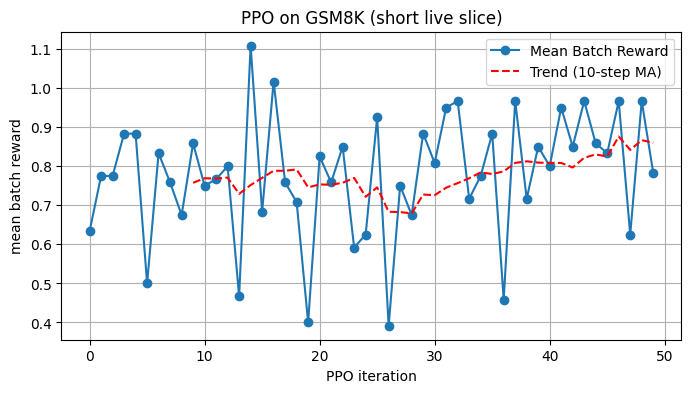

In [ ]:
if ppo_history:
    plt.figure(figsize=(8, 4))
    plt.plot(ppo_history, marker='o', label='Mean Batch Reward')

    # Calculate a simple moving average for the trend
    window_size = max(1, len(ppo_history) // 5) # Use 20% of data points for window size, minimum 1
    if len(ppo_history) >= window_size:
        trend = pd.Series(ppo_history).rolling(window=window_size).mean()
        plt.plot(trend, color='red', linestyle='--', label=f'Trend ({window_size}-step MA)')

    plt.xlabel('PPO iteration'); plt.ylabel('mean batch reward')
    plt.title('PPO on GSM8K (short live slice)')
    plt.grid(True)
    plt.legend()
    plt.show()

#if LIVE_PPO:
if True:
    image_url = "https://i.imgflip.com/3gzjfj.jpg"
    display(Image(url=image_url, width=400, height=265))

In [ ]:
import os
import torch
from google.colab import drive

# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define the directory to save the checkpoint
save_dir = '/content/drive/MyDrive/colab_checkpoints'
os.makedirs(save_dir, exist_ok=True)

# Define the path for the checkpoint file
checkpoint_path = os.path.join(save_dir, 'qwen2_5_0_5b_instruct_ppo_checkpoint.pth')

# Save the policy's state_dict
torch.save(policy.state_dict(), checkpoint_path)

print(f"Model checkpoint saved to: {checkpoint_path}")

Mounted at /content/drive
Model checkpoint saved to: /content/drive/MyDrive/colab_checkpoints/qwen2_5_0_5b_instruct_ppo_checkpoint.pth


In [ ]:
#@title 📚 Reference only: the same thing with `trl` (more or less).
# How you'd run PPO with the library instead of by hand.
#
# from trl.experimental.ppo import PPOTrainer, PPOConfig
#
# trainer = PPOTrainer(
#     args=PPOConfig(                      # our ppo_train hyperparameters
#         learning_rate=1e-4,
#         num_ppo_epochs=2,                #   ppo_epochs
#         cliprange=0.2,                   #   clip_eps
#         kl_coef=0.05,                    #   beta_kl
#         vf_coef=0.1,                     #   vf_coef
#         response_length=512,             #   GEN_KWARGS["max_new_tokens"]
#         per_device_train_batch_size=3,   # Number of samples per GPU/device
#         gradient_accumulation_steps=4,   # Steps before performing a backward/update pass
#     ),
#     model=base_model,                    # plain causal LM: the policy
#     peft_config=lora_config,             # TRL wraps it in LoRA for us
#     ref_model=None,                      # None -> TRL makes the reference copy
#                                          # (we used the LoRA-disable trick instead)
#     reward_model=reward_model,           # must be an nn.Module! A rule-based
#                                          # verifier like gsm8k_reward doesn't fit —
#                                          # you'd train a reward MODEL first (RLHF)
#                                          # or switch to GRPOTrainer, which accepts
#                                          # plain reward FUNCTIONS (next section).
#     value_model=value_model,             # a separate critic network
#                                          # (we bolted a linear head on the policy)
#     processing_class=tokenizer,
#     train_dataset=prompt_dataset,        # dataset of tokenized prompts
# )
# trainer.train()                          # rollout -> reward -> advantage -> clipped loss


In [ ]:
#@title Before vs. after: the SAME problems, base model vs. PPO-tuned policy.

question_id = -1
eval_question = gsm8k["test"]["question"][question_id]
eval_gold = gsm8k["test"]["answer"][question_id]


# Compare the output and reward of the base model and the PPO-tuned model
# Base model = tuned model with disabled adapter
with policy.lm.disable_adapter():
    answer_before = generate_answers([eval_question], max_new_tokens=512, do_sample=False)[0]
answer_after = generate_answers([eval_question], max_new_tokens=512, do_sample=False)[0]

reward_before = gsm8k_reward(answer_before, eval_gold)
reward_after = gsm8k_reward(answer_after, eval_gold)

print("=" * 80)
print(f"QUESTION: {eval_question}")
print(f"GOLD ANSWER: {extract_ground_truth(eval_gold)}")
print(f"\n--- BEFORE (base model)   reward = {reward_before:.1f} ---")
print(answer_before)   # show the tail, where the final answer lives
print(f"\n--- AFTER  (PPO-tuned)    reward = {reward_after:.1f} ---")
print(answer_after)

QUESTION: Henry and 3 of his friends order 7 pizzas for lunch. Each pizza is cut into 8 slices. If Henry and his friends want to share the pizzas equally, how many slices can each of them have?
GOLD ANSWER: 14

--- BEFORE (base model)   reward = 1.3 ---
To determine how many slices of pizza each person can have if they share the pizzas equally, we need to follow these steps:

1. Calculate the total number of pizza slices.
2. Divide the total number of slices by the number of people sharing the pizza.

First, let's calculate the total number of pizza slices. Since there are 7 pizzas and each pizza is cut into 8 slices, we multiply the number of pizzas by the number of slices per pizza:
\[ 7 \text{ pizzas} \times 8 \text{ slices per pizza} = 56 \text{ slices} \]

Next, we need to divide the total number of slices by the number of people sharing the pizza. There are 4 people (Henry and his 3 friends), so we divide 56 slices by 4:
\[ 56 \text{ slices} \div 4 \text{ people} = 14 \text{ slic

## 2.3 GRPO — drop the critic, trust the group

PPO needs a **value head** (the critic) to turn returns into advantages — a second network to train, tune, and store. **[Group Relative Policy Optimization (GRPO)](https://arxiv.org/abs/2402.03300)**, the algorithm behind DeepSeek-R1, removes it with one simple idea:

> For each prompt, sample a **group** of $G$ answers and let their rewards judge *each other*. An answer that beats its groupmates gets a **positive** advantage; a below-average one gets **negative**.

<img src="https://raw.githubusercontent.com/natolambert/rlhf-book/main/book/images/grpo_tikz.png" alt="ppo loop" width="500"/>

<sub>Figure from Nathan Lambert's [RLHF Book, Ch. 6 — Policy Gradients](https://rlhfbook.com/c/06-policy-gradients#group-relative-policy-optimization-grpo).</sub>

### The group-relative advantage
The whole trick is the **advantage**. Given the $G$ rewards $r_1,\dots,r_G$ for one prompt, standardize *within* the group:

$$A_i = \frac{r_i - \text{mean}(r_1,\dots,r_G)}{\text{std}(r_1,\dots,r_G) + \varepsilon}$$

The group mean **is** the baseline — it plays the role PPO's value function $V(s)$ played, but costs nothing to learn. Because our reward is an *outcome* signal that arrives only at the end (exactly like reaching the goal in CliffWalking), every token in completion $i$ shares the same scalar $A_i$.

### Everything else is PPO
Plug $A_i$ into the **same clipped surrogate + KL** you already implemented:

$$J(\theta) = \frac{1}{G}\sum_{i=1}^{G}\Big[\min\big(\rho_i A_i,\ \text{clip}(\rho_i,\, 1-\varepsilon,\, 1+\varepsilon)\,A_i\big) - \beta\,\mathcal{D}_{\text{KL}}\!\left(\pi_\theta \,\|\, \pi_{\text{ref}}\right)\Big], \qquad \rho_i = \frac{\pi_\theta(a_i\mid s)}{\pi_{\theta_{\text{old}}}(a_i\mid s)}$$

| | PPO | GRPO |
|---|---|---|
| **Baseline** | learned value head $V(s)$ | group mean reward |
| **Advantage** | $A_t = G_t - V(s_t)$ (per **token** $t$) | $A_i$ (per **completion** $i$, shared across its tokens) |
| **KL term** | in the loss (in our code; frameworks like TRL fold it into per-token rewards instead) | a term **in the loss** |
| **Extra model** | yes — the critic | **none** |

> 💡 Watch the index: PPO advantages are indexed by **token** $t$, GRPO advantages by **completion** $i$ in the group. Same clipped objective — only the way we estimate $A$ changes.

#### 🤔 Check your understanding

**Q1.** One prompt, a group of 4 answers. Which rewards produce the stronger learning signal: $(1,\ 1,\ 1,\ 1)$ or $(0,\ 0,\ 0,\ 0)$?

<details><summary>Answer</summary>

Trick question — they're **identical**: zero signal in both cases. The group mean equals every reward, so all advantages standardize to $\approx 0$, whether the group is all-correct or all-wrong. GRPO only learns from *disagreement within a group* — which is why it needs prompts that are neither too easy nor too hard for the current model. (The sanity-check cell below verifies exactly this.)
</details>

**Q2.** PPO's advantage carried a token index ($A_t$), GRPO's carries a rollout/completion index ($A_i$). Where did the per-token credit assignment go?

<details><summary>Answer</summary>

In PPO, the critic reads the sequence token by token, and $V(s_t)$ rises and falls along the way. If the model writes three good reasoning steps and then botches the arithmetic, $V(s_t)$ is high mid-sequence and the outcome is 0, so the *last* tokens get the most negative advantages — the critic **localizes the blame**.

In GRPO, every token of completion $i$ gets the same scalar $A_i$: one verdict per answer, "this whole completion was better/worse than its groupmates". The update $\sum_t A_i \nabla_\theta \log \pi_\theta(a_t)$ nudges *all* of its tokens up or down together — including the three good reasoning steps of a failed attempt.
</details>

In [ ]:
#@title ✏️ Exercise: implement the GRPO group-relative advantage (the whole trick).
def grpo_advantages(rewards, epsilon=1e-4):
    """rewards: tensor of shape [num_prompts, G]. Returns flat advantages [num_prompts*G]."""
    ################################################################
    # TODO: normalize rewards WITHIN each group (row), then flatten.
    #   A_i = (r_i - row_mean) / (row_std + 1e-4)
    # YOUR CODE HERE
    raise NotImplementedError()
    ################################################################

In [ ]:
# --- Sanity check (no GPU needed): a tied group has nothing to learn from ---
_tied = torch.full((2, 4), 0.5)                       # 2 groups, all rewards equal
assert torch.allclose(grpo_advantages(_tied), torch.zeros(8), atol=1e-3)
print("✅ Sanity: identical rewards in a group -> advantages ~ 0.")

✅ Sanity: identical rewards in a group -> advantages ~ 0.


In [ ]:
#@title ✏️ Exercise: reuse the PPO clipped loss with NO critic.
def grpo_loss(logp, logp_old, logp_ref, advantages, mask, clip_eps=0.2, beta_kl=0.04):
    """The PPO clipped surrogate + KL, with the critic switched off."""
    zeros = torch.zeros_like(mask)
    ################################################################
    # TODO: call ppo_clipped_loss, but with the critic switched OFF.
    # YOUR CODE HERE
    raise NotImplementedError()
    ################################################################


<details><summary>💡 Hints</summary>

* Pass the `zeros` tensor above for BOTH `returns` and `values` (the squared value error becomes 0).
* Set `vf_coef=0.0` so the value term is weighted out entirely.
* Everything else (`logp`, `logp_old`, `logp_ref`, `advantages`, `mask`, `clip_eps`, `beta_kl`) passes straight through; return what `ppo_clipped_loss` returns.
</details>

In [ ]:
def test_grpo_loss():
    B, T = 1, 4
    mask = torch.ones(B, T)
    zeros = torch.zeros(B, T)
    advantages = torch.full((B, T), 2.0)

    # Case 1: logp == logp_old == logp_ref, advantages = 2.0, no clipping, beta_kl=0.
    # Expected loss: -mean(advantages) = -2.0
    loss, info = grpo_loss(zeros, zeros, zeros, advantages, mask, clip_eps=0.2, beta_kl=0.0)
    assert torch.isclose(loss, torch.tensor(-2.0), atol=1e-5), f"Test 1 failed: Expected -2.0, got {loss.item()}"
    assert abs(info["kl"]) < 1e-6
    assert abs(info["value_loss"]) < 1e-6

    # Case 2: policy moved a lot (ratio = e ~ 2.72) with positive advantage
    # -> the clip must cap the surrogate at 1.2 * adv (2.0) = 2.4. KL and VF are still 0.
    logp_new = zeros + 1.0
    loss2, info2 = grpo_loss(logp_new, zeros, zeros, advantages, mask, clip_eps=0.2, beta_kl=0.0)
    assert torch.isclose(loss2, torch.tensor(-2.4), atol=1e-5), f"Test 2 failed: Expected -2.4, got {loss2.item()}"
    assert abs(info2["kl"]) < 1e-6

    # Case 3: Adding KL penalty. logp == logp_old, advantages=0. returns=0, values=0. Only KL contributes.
    # kl_surrogate = 0.5 * (logp - logp_ref) ** 2 = 0.5 * (0 - (-0.1))**2 = 0.005
    # loss = beta_kl * masked_mean(kl_surrogate) = 0.04 * 0.005 = 0.0002
    logp_ref_val = torch.full((B, T), -0.1)
    loss3, info3 = grpo_loss(zeros, zeros, logp_ref_val, zeros, mask, clip_eps=0.2, beta_kl=0.04)
    assert torch.isclose(loss3, torch.tensor(0.0002), atol=1e-5), f"Test 3 failed: Expected 0.0002, got {loss3.item()}"
    assert torch.isclose(torch.tensor(info3["kl_surrogate"]), torch.tensor(0.005), atol=1e-5)

    print("✅ GRPO loss tests passed!")

test_grpo_loss()


In [ ]:
#@title Helper function 3: sample a GROUP of answers per prompt, score, and group-normalize.
# GRPO analogue of the PPO rollout: no value head -- the advantage is the
# group-normalized reward, broadcast across every token of its completion.

@torch.no_grad()
def grpo_rollout(questions, gold_answers, group_size=4):
    """Sample `group_size` completions per prompt; advantage = group-normalized reward."""
    # Repeat each prompt G times so one generate() call covers a whole group.
    rep_q = [q for q in questions for _ in range(group_size)]
    rep_a = [a for a in gold_answers for _ in range(group_size)]
    prompts = [build_prompt(q) for q in rep_q]
    enc = tokenizer(prompts, return_tensors="pt", padding=True).to(device)
    prompt_len = enc.input_ids.shape[1]
    full_ids = policy.generate(
        input_ids=enc.input_ids, attention_mask=enc.attention_mask,
        pad_token_id=tokenizer.pad_token_id, **GEN_KWARGS)

    # Masks: same convention as the PPO rollout. resp_mask marks completion tokens.
    attention_mask = (full_ids != tokenizer.pad_token_id).long()
    resp_mask = torch.zeros_like(full_ids)
    resp_mask[:, prompt_len:] = 1
    resp_mask = (resp_mask & attention_mask)[:, 1:].float()         # (B, T-1)

    # Score every completion with our verifier reward.
    completions = tokenizer.batch_decode(full_ids[:, prompt_len:], skip_special_tokens=True)
    rewards = torch.tensor([gsm8k_reward(c, g) for c, g in zip(completions, rep_a)],
                           dtype=torch.float32, device=device)

    # GROUP-relative advantage: [num_prompts, G] -> normalize -> broadcast over tokens.
    adv_flat = grpo_advantages(rewards.view(len(questions), group_size))   # (B,)
    advantages = adv_flat.unsqueeze(1) * resp_mask                         # (B, T-1)

    # Old-policy + reference log-probs (no value head needed for GRPO).
    logits, _ = policy(full_ids, attention_mask)
    logp_old = token_logps(logits, full_ids)
    ref_logp = token_logps(policy.reference_logits(full_ids, attention_mask), full_ids)

    return {"full_ids": full_ids, "attention_mask": attention_mask, "resp_mask": resp_mask,
            "logp_old": logp_old, "ref_logp": ref_logp, "advantages": advantages,
            "mean_reward": rewards.mean().item(), "completions": completions}


### The GRPO training loop

Same skeleton as `ppo_train`, minus the critic. Each step:

1. **Collect**: for each of `prompts_per_batch` prompts, sample a **group** of `group_size` answers (one `grpo_rollout` call per prompt).
2. **Advantage**: already group-normalized inside the rollout — GRPO needs no separate whitening step.
3. **Update**: run `grpo_epochs` passes over the same experience, accumulating gradients across groups, with **one** optimizer step per epoch.

Read through the loop below, then run the short live slice.

In [ ]:
def grpo_train(questions, gold_answers, num_iters=15, prompts_per_batch=3, group_size=4,
               grpo_epochs=2, lr=1e-5, clip_eps=0.2, beta_kl=0.04):
    """A short, hand-rolled GRPO loop — same structure as ppo_train, minus the critic.

    One "chunk" = one prompt's group of `group_size` completions (the memory cap,
    playing the role minibatch_size played in ppo_train). A full batch is
    `prompts_per_batch` groups; gradients are accumulated across them and applied
    in ONE optimizer step per epoch.
    """
    optimizer = torch.optim.AdamW([p for p in policy.parameters() if p.requires_grad], lr=lr, weight_decay=0.01)
    history, cursor = [], 0

    iter_bar = tqdm(range(num_iters), desc="GRPO training")
    for it in iter_bar:

        # --- 1) COLLECT: one rollout per prompt = its whole group of G answers.
        batch_chunks = []
        for _ in range(prompts_per_batch):
            batch_q = questions[cursor:cursor + 1]
            batch_a = gold_answers[cursor:cursor + 1]
            cursor = (cursor + 1) % len(questions)
            batch_chunks.append(grpo_rollout(batch_q, batch_a, group_size=group_size))

        # --- 2) (PPO whitened advantages here.) GRPO needs NO extra step,
        #     since whitening is part of the algorithm

        # --- 3) UPDATE: epochs over the SAME experience; accumulate gradients
        #     across the chunks (scaled to the full-batch mean), ONE step per epoch.
        num_chunks = len(batch_chunks)
        for _ in range(grpo_epochs):
            optimizer.zero_grad()
            chunk_infos = []
            for data in batch_chunks:
                if device == "cuda":
                    torch.cuda.empty_cache()   # free the previous chunk's blocks
                logits, _ = policy(data['full_ids'], data['attention_mask'])
                logp = token_logps(logits, data['full_ids'])
                loss, info = grpo_loss(logp, data['logp_old'], data['ref_logp'],
                                       data['advantages'], data['resp_mask'],
                                       clip_eps=clip_eps, beta_kl=beta_kl)
                (loss / num_chunks).backward()
                info['loss'] = loss.item()
                chunk_infos.append(info)
                del logits, logp, loss     # drop graph references before the next chunk
            torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
            optimizer.step()

        # --- LOGGING: reward averaged over the full batch of groups.
        mean_reward = float(np.mean([c['mean_reward'] for c in batch_chunks]))
        mean_info = {k: float(np.mean([ci[k] for ci in chunk_infos])) for k in chunk_infos[0]}
        history.append(mean_reward)

        iter_bar.set_postfix(reward=f"{mean_reward:.3f}",
                             kl=f"{mean_info['kl']:.4f}",
                             loss=f"{mean_info['loss']:.3f}")
        tqdm.write(f"iter {it:3d} | mean reward {mean_reward:.3f} | "
                   f"KL {mean_info['kl']:.4f} | loss {mean_info['loss']:.3f}")
    return history

In [ ]:
### RUN THIS TO RESET THE MODEL TO BASE STATE BEFORE TRAINING GRPO ###
# Remove the PPO-trained LoRA adapter WITHOUT merging it into the base weights.
fresh_base_model = policy.lm.unload()
del policy

# Attach newly initialized LoRA parameters and create a fresh value head.
base_model = fresh_base_model
policy = PolicyWithValueHead(base_model, lora_config).to(device)
del fresh_base_model
print("Policy reset to the original base model with fresh LoRA parameters.")

Policy reset to the original base model with fresh LoRA parameters.


In [ ]:
#@title Run a short hand-rolled GRPO slice and plot the reward curve.
# A SHORT live slice (like the PPO one). For a real improvement you'd train
# @markdown 🧭🧭🧭Select this in class to run just a few steps!!!
LIVE_GRPO = True  # @param {type:"boolean"}

grpo_history = grpo_train(
    train_q,
    train_a,
    num_iters=5 if LIVE_GRPO else 50,
    group_size=4,
)

GRPO training:   0%|          | 0/50 [00:00<?, ?it/s]

iter   0 | mean reward 0.667 | KL 0.0016 | loss -0.106
iter   1 | mean reward 0.717 | KL 0.0005 | loss -0.001
iter   2 | mean reward 0.683 | KL 0.0010 | loss 0.091
iter   3 | mean reward 0.258 | KL 0.0009 | loss 0.081
iter   4 | mean reward 0.967 | KL 0.0006 | loss -0.032
iter   5 | mean reward 0.325 | KL 0.0014 | loss 0.028
iter   6 | mean reward 0.608 | KL 0.0005 | loss 0.051
iter   7 | mean reward 0.633 | KL 0.0008 | loss 0.068
iter   8 | mean reward 0.875 | KL 0.0008 | loss 0.176
iter   9 | mean reward 0.767 | KL 0.0016 | loss 0.070
iter  10 | mean reward 0.783 | KL 0.0008 | loss -0.044
iter  11 | mean reward 1.175 | KL 0.0009 | loss 0.181
iter  12 | mean reward 0.650 | KL 0.0008 | loss 0.101
iter  13 | mean reward 0.967 | KL 0.0006 | loss 0.000
iter  14 | mean reward 1.008 | KL 0.0007 | loss 0.003
iter  15 | mean reward 0.775 | KL 0.0015 | loss 0.075
iter  16 | mean reward 0.883 | KL 0.0013 | loss 0.054
iter  17 | mean reward 0.925 | KL 0.0019 | loss 0.041
iter  18 | mean reward 1

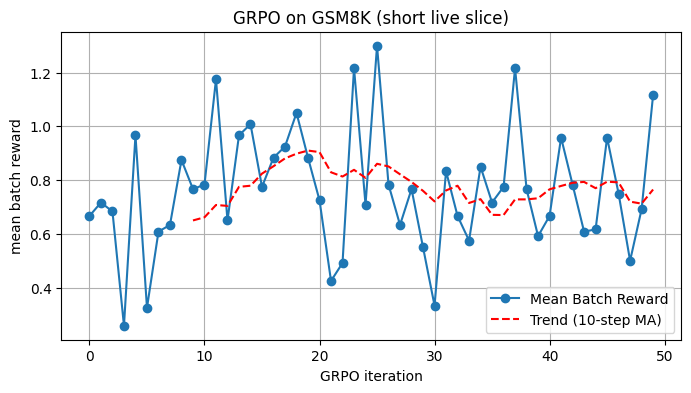

In [ ]:
if grpo_history:
    plt.figure(figsize=(8, 4))
    plt.plot(grpo_history, marker='o', label='Mean Batch Reward')

    # Calculate a simple moving average for the trend
    window_size = max(1, len(grpo_history) // 5) # Use 20% of data points for window size, minimum 1
    if len(grpo_history) >= window_size:
        trend = pd.Series(grpo_history).rolling(window=window_size).mean()
        plt.plot(trend, color='red', linestyle='--', label=f'Trend ({window_size}-step MA)')

    plt.xlabel('GRPO iteration'); plt.ylabel('mean batch reward')
    plt.title('GRPO on GSM8K (short live slice)')
    plt.grid(True)
    plt.legend()
    plt.show()

if LIVE_GRPO:
    image_url = "https://i.imgflip.com/3gzjfj.jpg"
    display(Image(url=image_url, width=400, height=265))

In [ ]:
import os
import torch
from google.colab import drive

# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define the directory to save the checkpoint
save_dir = '/content/drive/MyDrive/colab_checkpoints'
os.makedirs(save_dir, exist_ok=True)

# Define the path for the checkpoint file
checkpoint_path = os.path.join(save_dir, 'qwen2_5_0_5b_instruct_grpo_checkpoint.pth')

# Save the policy's state_dict
torch.save(policy.state_dict(), checkpoint_path)

print(f"Model checkpoint saved to: {checkpoint_path}")

In [ ]:
#@title 📚 Reference: train GRPO with `trl.GRPOTrainer`
# from trl import GRPOTrainer, GRPOConfig

# G = 4  # generations per prompt (the "group")

# # TRL calls reward funcs as reward_func(prompts=..., completions=..., **dataset_cols).
# # Our rows keep their gold `answer` column, so it arrives here as a kwarg.
# def reward_func(completions, answer, **kwargs):
#     return [gsm8k_reward(c, a) for c, a in zip(completions, answer)]

# # Dataset: a chat-templated `prompt` + the gold `answer` (used only by the reward).
# def to_grpo_row(ex):
#     return {"prompt": build_prompt(ex["question"]), "answer": ex["answer"]}

# grpo_ds = gsm8k["train"].map(
#     to_grpo_row, remove_columns=gsm8k["train"].column_names)

# grpo_cfg = GRPOConfig(
#     output_dir="grpo_trl_out",
#     per_device_train_batch_size=4,    # must be divisible by num_generations
#     num_generations=G,
#     max_completion_length=200,
#     max_steps=10,                     # short live slice; bump this up offline
#     learning_rate=1e-5,
#     beta=0.04,                        # KL coefficient against the reference model
#     logging_steps=1,
#     report_to="none",
# )

# grpo_trainer = GRPOTrainer(
#     model=MODEL_NAME,
#     reward_funcs=reward_func,
#     args=grpo_cfg,
#     train_dataset=grpo_ds,
#     peft_config=lora_config,
# )
# grpo_trainer.train()


## 2.4 [Extra] DPO — skip the sampling, skip the reward model 🕐🕐🕐

PPO and GRPO are **online** algorithms: every single update starts with an expensive `generate()` call. And in the general RLHF setting (no verifier!), you first need to train a **reward model** on human preference data before you can even start.

**[Direct Preference Optimization](https://arxiv.org/abs/2305.18290) (DPO)** asks: if what we ultimately have is a dataset of preferences — *"for this prompt, answer A is better than answer B"* — can we optimize the policy on it **directly**? No reward model, no sampling loop - we do alignment for free (i.e. no RL):

<img src="https://arxiv.org/html/2305.18290v3/figures/diagrams/teaser.png" alt="ppo loop" width="500"/>

<sub>Figure 1 from the [DPO paper](https://arxiv.org/abs/2305.18290): RLHF trains a reward model and then runs RL against it; DPO collapses both stages into one supervised-looking loss.</sub>


### The idea in three steps

**Step 1 — How preferences become probabilities.** The standard way to model "answer $y_w$ beats answer $y_l$" is the **Bradley–Terry model**: the win probability depends only on the *difference* in their (unknown) rewards,

$$P(y_w \succ y_l \mid x) = \sigma\big(r(x, y_w) - r(x, y_l)\big)$$

where $\sigma$ is the sigmoid. A reward model is normally trained by maximizing the likelihood of the human labels under this model.

**Step 2 — The policy *is* a reward model (the key insight).** The RLHF objective we've been optimizing all along — *maximize reward, but stay close to the reference* — has a **closed-form optimal policy**. Inverting that closed form shows that the reward can be written in terms of the policy itself:

$$r(x, y) = \underbrace{\beta \log \frac{\pi_\theta(y \mid x)}{\pi_{ref}(y \mid x)}}_{\text{the implicit reward}} + \underbrace{\beta \log Z(x)}_{\text{depends only on the prompt}}$$

In words: *how much more likely the policy makes an answer, compared to the reference,* is itself a reward. Hence the paper's title.

**Step 3 — Substitute and watch the hard part vanish.** Plug this implicit reward into Bradley–Terry. Both answers share the same prompt $x$, so the intractable $\beta \log Z(x)$ term **cancels** in the difference, leaving a loss with only things we can compute:

$$\mathcal{L}_{DPO} = -\log \sigma\Big(\beta\big[\underbrace{\log\tfrac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)}}_{\text{implicit reward of chosen}} - \underbrace{\log\tfrac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)}}_{\text{implicit reward of rejected}}\big]\Big)$$

### How to read this loss

* The bracket is the **implicit reward margin**: how much more the policy has moved *toward* the chosen answer than toward the rejected one (both measured relative to the reference). Training pushes this margin up.
* $-\log\sigma(\cdot)$ is exactly **binary cross-entropy** — DPO is a classifier that must tell chosen from rejected. When the margin is $0$ (e.g. at initialization, where $\pi_\theta = \pi_{ref}$), the loss is $-\log\sigma(0) = \log 2$: a coin flip.
* $\beta$ plays the same role as the KL coefficient in PPO/GRPO: **larger $\beta$** → less deviation from the reference; **smaller $\beta$** → more freedom to fit the preferences and move away from the reference.


<details>
<summary> [Q]: If DPO is so cool, why don't we abandon PPO/GRPO then?</summary>

DPO is **offline**: it only ever sees the pairs in the dataset, never its own fresh mistakes.

There is also a subtler issue, hiding in plain sight in the loss itself. The loss only cares about the **gap** between the two implicit rewards — so there are two ways to make it happy:

1. make the **chosen** answer *more* likely (what we wanted), or
2. make the **rejected** answer *less* likely (also fine on its own).

Nothing in the loss says the chosen answer's probability must actually go **up**. And in practice, something counterintuitive often happens: the probabilities of **both** answers go *down* — the rejected one just falls **faster**, so the gap still grows and the loss still improves. The probability mass doesn't move from the rejected answer to the chosen one; it leaks away to *other sequences entirely*, ones that never appear in the training data. This phenomenon is sometimes called *displacement*:

<img src="https://raw.githubusercontent.com/natolambert/rlhf-book/main/book/images/dpo_displacement.png" alt="ppo loop" width="500"/>

<sub>Both curves fall, but the *gap* between them widens — which is all the DPO loss asks for. Figure from Nathan Lambert's [RLHF Book, Ch. 12 — Direct Alignment Algorithms](https://rlhfbook.com/c/12-direct-alignment).</sub>


Online methods (PPO/GRPO) are less exposed to this: they always evaluate the policy on its *own current* samples, so if quality drifts, the reward notices immediately. This online-vs-offline tension is an active research area (iterated/online DPO, etc.).
</details>

#### ✏️ Exercise: implement the DPO loss

In the next cell, translate $\mathcal{L}_{DPO}$ into code. Each argument is a **sequence-level** log-probability, $\log \pi(y|x) = \sum_t \log \pi(y_t \mid x, y_{<t})$, i.e. the per-token log-probs (our old friend `token_logps`) summed over the completion tokens — one scalar per example.

<details>
<summary>💡 Hints</summary>

* Two equivalent routes to the margin — pick either:
  - *Follow the formula*: `reward_chosen = logp_pol_chosen - logp_ref_chosen`, `reward_rejected = logp_pol_rejected - logp_ref_rejected`, `margin = reward_chosen - reward_rejected`.
  - *Regroup*: `pol_logratio = logp_pol_chosen - logp_pol_rejected`, `ref_logratio = logp_ref_chosen - logp_ref_rejected`, `margin = pol_logratio - ref_logratio`.
  The algebra is identical; the reference solution uses the second.
* Use `F.logsigmoid(...)` rather than `torch.log(torch.sigmoid(...))` — mathematically identical, numerically much safer for large negative arguments.
* The loss is the **mean** over the batch of `-logsigmoid(beta * margin)`.
* For `info`, report the mean margin and the fraction of pairs where the margin is positive (the implicit reward already ranks them correctly).
</details>


In [ ]:
#@title ✏️ Exercise: Implement the DPO loss.
def dpo_loss(logp_pol_chosen, logp_pol_rejected,
             logp_ref_chosen, logp_ref_rejected, beta=0.1):
    """DPO loss for a batch of preference pairs.

    Each arg is a tensor of shape (B,): the SEQUENCE log-prob of the chosen /
    rejected completion under the policy / the frozen reference.

    Returns (loss, info_dict).
    """
    ################################################################
    # TODO: build the DPO loss.
    #   pol_logratio = logp_pol_chosen - logp_pol_rejected
    #   ref_logratio = logp_ref_chosen - logp_ref_rejected
    #   margin       = pol_logratio - ref_logratio      # implicit reward margin
    #   loss         = -F.logsigmoid(beta * margin).mean()
    # YOUR CODE HERE
    raise NotImplementedError()
    ################################################################
    return loss, info


In [ ]:
#@title Test your DPO loss.
def test_dpo_loss():
    # Case 1: policy == reference. The margin is 0, so the loss must be
    # exactly -log(sigmoid(0)) = log(2) ~= 0.6931 -- a coin flip.
    z = torch.zeros(3)
    pol_c, pol_r = torch.tensor([-5., -8., -2.]), torch.tensor([-7., -3., -4.])
    loss, info = dpo_loss(pol_c, pol_r, pol_c.clone(), pol_r.clone(), beta=0.1)
    assert torch.isclose(loss, torch.tensor(0.6931), atol=1e-3), f"got {loss}"
    assert abs(info["margin"]) < 1e-6

    # Case 2: policy prefers the chosen answer by +1 nat more than the reference
    # does. Expected: -log(sigmoid(0.1 * 1)) ~= 0.6444 < log(2).
    loss2, info2 = dpo_loss(z + 1.0, z, z, z, beta=0.1)
    assert torch.isclose(loss2, torch.tensor(0.6444), atol=1e-3), f"got {loss2}"
    assert info2["implicit_acc"] == 1.0

    # Case 3: shifting BOTH policy log-probs by the same constant changes
    # nothing -- only the chosen-vs-rejected DIFFERENCE matters.
    loss3, _ = dpo_loss(z + 1.0 - 5.0, z - 5.0, z, z, beta=0.1)
    assert torch.isclose(loss2, loss3, atol=1e-6)

    # Case 4: a bigger margin must mean a smaller loss (and vice versa).
    loss_good, _ = dpo_loss(z + 3.0, z, z, z, beta=0.1)
    loss_bad, _  = dpo_loss(z - 3.0, z, z, z, beta=0.1)
    assert loss_good < loss2 < loss_bad

    print("PASSED: loss(margin=0) = log 2, reference cancels shifts, "
          "bigger margin -> smaller loss")

test_dpo_loss()


PASSED: loss(margin=0) = log 2, reference cancels shifts, bigger margin -> smaller loss


In [ ]:
# 🏠 Take-home exercise (nothing to run in class):
#   1. Build a preference dataset with the cell below (pref_ds).
#   2. Train: DPOTrainer(model=..., args=DPOConfig(beta=0.1), train_dataset=pref_ds,
#             processing_class=tokenizer, peft_config=lora_config).train()
#   3. Compare online (GRPO) vs offline (DPO) accuracy on held-out problems.

In [ ]:
#@title Your DPO loss on a REAL pair, with our actual model.
# Let's feed dpo_loss real numbers: one correct and one wrong answer to a GSM8K
# problem, scored by our policy (LoRA adapter ON) and the reference (adapter OFF)
# -- the same memory trick we used for the PPO/GRPO KL term.

@torch.no_grad()
def completion_logp(question: str, completion: str, use_ref: bool = False):
    """Sequence log-prob log pi(completion | prompt): token_logps summed over
    the completion tokens."""
    prompt = build_prompt(question)
    n_prompt = tokenizer(prompt, return_tensors="pt").input_ids.shape[1]
    full_ids = tokenizer(prompt + completion, return_tensors="pt").input_ids.to(device)
    attn = torch.ones_like(full_ids)
    logits = (policy.reference_logits(full_ids, attn) if use_ref
              else policy(full_ids, attn)[0])
    # token_logps index t holds log p(token t+1), so completion tokens start at n_prompt-1.
    return token_logps(logits, full_ids)[0, n_prompt - 1:].sum()


ex = gsm8k["test"][0]
gold = extract_ground_truth(ex["answer"])
chosen   = ex["answer"].split("####")[0].strip() + f" The final answer is \\boxed{{{gold}}}."
rejected = f"This looks hard, so I will just guess. The final answer is \\boxed{{{int(float(gold)) + 5}}}."

loss, info = dpo_loss(
    logp_pol_chosen=completion_logp(ex["question"], chosen).unsqueeze(0),
    logp_pol_rejected=completion_logp(ex["question"], rejected).unsqueeze(0),
    logp_ref_chosen=completion_logp(ex["question"], chosen, use_ref=True).unsqueeze(0),
    logp_ref_rejected=completion_logp(ex["question"], rejected, use_ref=True).unsqueeze(0),
)
print(f"DPO loss on this pair: {loss.item():.4f}  (log 2 = 0.6931 would mean 'no preference yet')")
print(f"Implicit reward margin: {info['margin']:.4f}")


DPO loss on this pair: 0.5981  (log 2 = 0.6931 would mean 'no preference yet')
Implicit reward margin: 2.0000


In [ ]:
#@title Build a preference set from the model's own answers.
# Where do the pairs come from? We let our (GRPO-tuned) policy answer each
# problem K times, then use the verifier as the "human" annotator:
#     correct answer  -> chosen      wrong answer -> rejected.
from datasets import Dataset

N_PROMPTS = 16   # short live slice; scale these up offline
K = 4            # answers sampled per problem

pref_rows = []
for ex in tqdm(gsm8k["train"].select(range(N_PROMPTS)), desc="building pairs"):
    outs = generate_answers([ex["question"]] * K, max_new_tokens=256, temperature=0.9)
    scored = sorted(((gsm8k_reward(o, ex["answer"]), o) for o in outs), key=lambda t: t[0])
    worst_r, worst = scored[0]
    best_r, best = scored[-1]
    if best_r >= 1.0 and worst_r < 1.0:   # need one correct AND one wrong
        pref_rows.append({
            # Conversational format: trl applies the chat template for us.
            "prompt": [{"role": "system", "content": SYSTEM_PROMPT},
                       {"role": "user", "content": ex["question"]}],
            "chosen": [{"role": "assistant", "content": best}],
            "rejected": [{"role": "assistant", "content": worst}],
        })

pref_ds = Dataset.from_list(pref_rows)
print(f"Kept {len(pref_ds)}/{N_PROMPTS} prompts (needed >=1 correct and >=1 wrong answer).")
print(pref_ds)
print(pref_ds[0])

building pairs:   0%|          | 0/16 [00:00<?, ?it/s]

Kept 8/16 prompts (needed >=1 correct and >=1 wrong answer).
Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 8
})
{'prompt': [{'role': 'system', 'content': 'You are a helpful math assistant. Solve the problem step by step, then give the final numerical answer inside \\boxed{...}.'}, {'role': 'user', 'content': 'Weng earns $12 an hour for babysitting. Yesterday, she just did 50 minutes of babysitting. How much did she earn?'}], 'chosen': [{'role': 'assistant', 'content': 'To determine how much Weng earned for babysitting 50 minutes, we need to follow these steps:\n\n1. Convert the time from minutes to hours since the hourly wage is given in dollars per hour.\n2. Calculate her earnings based on her hourly wage.\n\nFirst, we know that there are 60 minutes in an hour. Therefore, 50 minutes is equal to:\n\\[\n\\frac{50}{60} = \\frac{5}{6} \\text{ hours}\n\\]\n\nNext, we multiply her hourly wage (which is $12) by the time spent working in hours:\n\\[\n12 \\times \\fra

## 🎉 Wrap-up

You've connected the full arc — from a tabular gridworld agent to aligning a real LLM:

- **REINFORCE** → policy gradients from raw returns.
- **PPO** → critic-based advantages + a clipped, KL-regularized objective.
- **GRPO** → the same objective, but the *group* replaces the critic.
- **DPO** (not in class) → skip sampling entirely; optimize preferences in closed form (basically, not RL at all).

### Where to go next
- 📘 **The RLHF Book** — https://rlhfbook.com/
- 📘 **Build a Reasoning Model (From Scratch)** = https://github.com/rasbt/reasoning-from-scratch
- 📘 **On the policy gradient "loss" (by Clare Lyle)** - https://clarelyle.com/posts/2026-02-26-not-a-loss.html


Thanks for joining — happy aligning!